In [ ]:
import pandas as pd
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt

In [42]:
# Task 1: Data Validation and Schema Inspection


# --- 1. Load rides data ---
base_dir = Path(r"C:\Users\Daniel Loh\Documents\NUS-ISS_EBAC\BDA\BDA Project Module\silver\ride_year=2025")
if not base_dir.exists():
    raise FileNotFoundError(f"Missing rides path: {base_dir}")

rides_df = pd.read_parquet(base_dir, engine="pyarrow")

print("Row count:", f"{len(rides_df):,}")
print("Column count:", len(rides_df.columns))
print("\nSchema preview:")
print(rides_df.dtypes)

# --- 2. Identify candidate fields ---
candidate_station_cols = [c for c in rides_df.columns if "canonical_station_id" in c]
candidate_time_cols = [c for c in rides_df.columns if any(k in c.lower() for k in ["time", "date", "ts", "timestamp"])]

print("\nCandidate canonical station columns:", candidate_station_cols)
print("Candidate time/date columns:", candidate_time_cols)

# --- 3. Select pilot station ---
if "start_canonical_station_id" not in rides_df.columns:
    raise ValueError("No start_canonical_station_id found in schema.")

pilot_station_id = (
    rides_df["start_canonical_station_id"]
    .dropna()
    .sort_values()
    .iloc[0]
)

print("\nPilot canonical_station_id selected:", pilot_station_id)

# --- 4. Quick coverage check ---
coverage_counts = {
    "start_id_non_null": rides_df["start_canonical_station_id"].notna().sum(),
    "end_id_non_null": rides_df["end_canonical_station_id"].notna().sum(),
    "total_rows": len(rides_df),
}
print("\nCoverage counts:", coverage_counts)

# --- 5. Sample preview ---
print("\nSample rows:")
print(rides_df.head(10))

Row count: 14,251,175
Column count: 18

Schema preview:
end_station_key                       object
start_station_key                     object
start_station_name                    object
start_station_district                object
start_station_latitude               float64
start_station_longitude              float64
end_station_name                      object
end_station_district                  object
end_station_latitude                 float64
end_station_longitude                float64
start_time_ms                 datetime64[ns]
end_time_ms                   datetime64[ns]
start_station_name_norm               object
end_station_name_norm                 object
start_coord_key                       object
end_coord_key                         object
start_canonical_station_id            object
end_canonical_station_id              object
dtype: object

Candidate canonical station columns: ['start_canonical_station_id', 'end_canonical_station_id']
Candidate time/date col

In [69]:


# Load GBFS feeds with pandas
info_url   = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"
status_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_status.json"

info_data   = pd.read_json(info_url)
status_data = pd.read_json(status_url)

# Normalize into DataFrames
info_df   = pd.json_normalize(info_data['data']['stations'])
status_df = pd.json_normalize(status_data['data']['stations'])

# Output column headers
print("info_df columns:")
print(info_df.columns.tolist())

print("\nstatus_df columns:")
print(status_df.columns.tolist())


print(rides_df.columns.tolist())

info_df columns:
['station_id', 'external_id', 'name', 'short_name', 'lat', 'lon', 'rental_methods', 'capacity', 'electric_bike_surcharge_waiver', 'is_charging', 'eightd_has_key_dispenser', 'has_kiosk']

status_df columns:
['station_id', 'num_bikes_available', 'num_ebikes_available', 'vehicle_types_available', 'num_bikes_disabled', 'num_docks_available', 'num_docks_disabled', 'is_installed', 'is_renting', 'is_returning', 'last_reported', 'eightd_has_available_keys', 'is_charging']
['end_station_key', 'start_station_key', 'start_station_name', 'start_station_district', 'start_station_latitude', 'start_station_longitude', 'end_station_name', 'end_station_district', 'end_station_latitude', 'end_station_longitude', 'start_time_ms', 'end_time_ms', 'start_station_name_norm', 'end_station_name_norm', 'start_coord_key', 'end_coord_key', 'start_canonical_station_id', 'end_canonical_station_id', 'start_time', 'end_time']


In [44]:


# --- Load GBFS station information directly with pandas ---
info_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"
info_data = pd.read_json(info_url)

# Normalize into DataFrame
info_df = pd.json_normalize(info_data['data']['stations'])

# --- Compute median capacity ---
if "capacity" in info_df.columns:
    capacity_override = int(info_df["capacity"].median())
    print("Capacity override set to median capacity:", capacity_override)
else:
    raise ValueError("No 'capacity' column found in info_df")

# --- Initial bikes override (optional) ---
initial_bikes_override = None  # Example: set to 20 if known snapshot exists

# --- Resolve station capacity ---
station_capacity = float(capacity_override)

# --- Resolve initial bikes ---

initial_bikes = (
    int(initial_bikes_override)
    if initial_bikes_override is not None
    else math.floor(0.5 * station_capacity)
)


print("Station capacity used:", station_capacity)
print("Initial bikes used:", initial_bikes)
print("Capacity source: median from GBFS info_df")

Capacity override set to median capacity: 21
Station capacity used: 21.0
Initial bikes used: 10
Capacity source: median from GBFS info_df


In [45]:

# --- Define mapping directory and file ---
mapping_csv_dir = Path(r"C:\Users\Daniel Loh\Documents\NUS-ISS_EBAC\BDA\BDA Project Module\silver\station_direct_match_mapping_csv")
mapping_file = mapping_csv_dir / "part-00000-05727353-4315-467e-811a-270e04e821e6-c000.csv"

# --- Load mapping CSV ---
if not mapping_file.exists():
    raise FileNotFoundError(f"Expected mapping file not found: {mapping_file}")

canonical_mapping_df = pd.read_csv(mapping_file)
mapping_source = str(mapping_file)

# --- Validate required columns ---
required_map_cols = [
    "canonical_station_id",
    "canonical_lat",
    "canonical_lon",
    "normalized_name",
    "coord_key",
]
missing_map_cols = [c for c in required_map_cols if c not in canonical_mapping_df.columns]
if missing_map_cols:
    raise ValueError(f"Missing required mapping columns: {missing_map_cols}")

# --- Report summary ---
print("Mapping source:", mapping_source)
print("Mapping rows:", f"{len(canonical_mapping_df):,}")
print("Canonical stations:", canonical_mapping_df["canonical_station_id"].nunique())

# --- Preview required columns ---
print("\nPreview of required mapping columns:")
print(canonical_mapping_df[required_map_cols].tail(10))

Mapping source: C:\Users\Daniel Loh\Documents\NUS-ISS_EBAC\BDA\BDA Project Module\silver\station_direct_match_mapping_csv\part-00000-05727353-4315-467e-811a-270e04e821e6-c000.csv
Mapping rows: 1,901
Canonical stations: 1422

Preview of required mapping columns:
     canonical_station_id  canonical_lat  canonical_lon  \
1891             STN_1079      45.639123     -73.596112   
1892             STN_1174      45.640003     -73.490113   
1893             STN_1148      45.640138     -73.492357   
1894             STN_1092      45.641415     -73.499957   
1895             STN_1311      45.641427     -73.500654   
1896             STN_1088      45.649546     -73.491915   
1897             STN_1076      45.651406     -73.500413   
1898             STN_1151      45.692233     -73.637031   
1899             STN_1216      45.697815     -73.654065   
1900             STN_1220      45.702349     -73.639578   

                                        normalized_name             coord_key  
1891  pa

In [46]:

# --- Load GBFS feeds ---
info_url   = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"
status_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_status.json"

info_data   = pd.read_json(info_url)
status_data = pd.read_json(status_url)

info_df   = pd.json_normalize(info_data['data']['stations'])
status_df = pd.json_normalize(status_data['data']['stations'])

# Merge live info + status
live_stations_df = pd.merge(info_df, status_df, on="station_id", how="inner")

# --- Load canonical mapping (your CSV) ---
mapping_file = r"C:\Users\Daniel Loh\Documents\NUS-ISS_EBAC\BDA\BDA Project Module\silver\station_direct_match_mapping_csv\part-00000-05727353-4315-467e-811a-270e04e821e6-c000.csv"
canonical_mapping_df = pd.read_csv(mapping_file)

# --- Resolver class (simplified for Task 2) ---
class CanonicalStationResolver:
    def __init__(self, canonical_mapping: pd.DataFrame, max_nearest_km: float = 0.05):
        self.canon_station_centers = (
            canonical_mapping[["canonical_station_id", "canonical_lat", "canonical_lon"]]
            .dropna()
            .drop_duplicates("canonical_station_id")
            .reset_index(drop=True)
        )
        self.center_lats = self.canon_station_centers["canonical_lat"].to_numpy()
        self.center_lons = self.canon_station_centers["canonical_lon"].to_numpy()
        self.ids = self.canon_station_centers["canonical_station_id"].to_numpy()
        self.max_nearest_km = max_nearest_km

    @staticmethod
    def _haversine_km_vec(lat1, lon1, lat2, lon2):
        r = 6371.0
        lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
        lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
        dlat, dlon = lat2_rad - lat1_rad, lon2_rad - lon1_rad
        a = np.sin(dlat/2)**2 + np.cos(lat1_rad)*np.cos(lat2_rad)*np.sin(dlon/2)**2
        return 2 * r * np.arcsin(np.sqrt(a))

    def resolve(self, lat, lon):
        dists = self._haversine_km_vec(lat, lon, self.center_lats, self.center_lons)
        min_pos = int(np.argmin(dists))
        min_dist = float(dists[min_pos])
        if min_dist <= self.max_nearest_km:
            return self.ids[min_pos]
        return None

# --- Instantiate resolver ---
resolver = CanonicalStationResolver(canonical_mapping_df)

# --- Example: resolve pilot station ---
pilot_station_id = "STN_0002"   # your chosen pilot
# Suppose you know pilot lat/lon from canonical mapping
pilot_row = canonical_mapping_df[canonical_mapping_df["canonical_station_id"] == pilot_station_id]
if not pilot_row.empty:
    pilot_lat, pilot_lon = pilot_row.iloc[0]["canonical_lat"], pilot_row.iloc[0]["canonical_lon"]
    resolved_id = resolver.resolve(pilot_lat, pilot_lon)
else:
    resolved_id = None

# --- Infer capacity ---
if resolved_id is not None:
    # Find live station(s) that mapped to this canonical ID
    pilot_live_rows = live_stations_df[
        (live_stations_df["lat"].round(5) == round(pilot_lat, 5)) &
        (live_stations_df["lon"].round(5) == round(pilot_lon, 5))
    ]
    if not pilot_live_rows.empty and "capacity" in pilot_live_rows.columns:
        pilot_capacity = int(pilot_live_rows["capacity"].max())
    else:
        pilot_capacity = int(info_df["capacity"].median())  # fallback
else:
    pilot_capacity = int(info_df["capacity"].median())      # fallback

# --- Initial bikes (rounded down) ---
initial_bikes = math.floor(0.5 * pilot_capacity)

print(f"Pilot station {pilot_station_id} inferred capacity:", pilot_capacity)
print("Initial bikes used:", initial_bikes)

Pilot station STN_0002 inferred capacity: 39
Initial bikes used: 19


In [49]:

import pandas as pd
# --- Load rides data ---
rides_path = r"C:\Users\Daniel Loh\Documents\NUS-ISS_EBAC\BDA\BDA Project Module\silver\ride_year=2025"
rides_df = pd.read_parquet(rides_path, engine="pyarrow")
#Convert timestamp
rides_df['end_time'] = pd.to_datetime(rides_df['end_time_ms'])
#--- Select pilot station ---
station_id = "STN_0001"   # your identified station
#--- Aggregate inflow/outflow at 30-min bins ---
inflow = ( rides_df[rides_df['start_canonical_station_id'] == station_id] .groupby(pd.Grouper(key='end_time', freq='30min')) .size() .reset_index(name='inflow') )
outflow = ( rides_df[rides_df['end_canonical_station_id'] == station_id] .groupby(pd.Grouper(key='end_time', freq='30min')) .size() .reset_index(name='outflow') )
flows = pd.merge(inflow, outflow, on='end_time', how='outer').fillna(0) 
flows['net_flow'] = flows['inflow'] - flows['outflow']
flows['actual_cumsum'] = flows['net_flow'].cumsum()
#--- Split train/test ---
flows_may = flows[(flows['end_time'].dt.month == 5) & (flows['end_time'].dt.year == 2025)]
flows_june = flows[(flows['end_time'].dt.month == 6) & (flows['end_time'].dt.year == 2025)]
print("Train (May) rows:", len(flows_may)) 
print("Test (June) rows:", len(flows_june))


Train (May) rows: 1488
Test (June) rows: 1440


In [50]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
import matplotlib.pyplot as plt

# --- Prepare StatsForecast inputs ---
sf_inflow = flows_may[['end_time','inflow']].rename(columns={'end_time':'ds','inflow':'y'})
sf_inflow['unique_id'] = station_id + "_inflow"
sf_inflow['ds'] = pd.to_datetime(sf_inflow['ds'])
sf_inflow = sf_inflow.sort_values('ds').reset_index(drop=True)

sf_outflow = flows_may[['end_time','outflow']].rename(columns={'end_time':'ds','outflow':'y'})
sf_outflow['unique_id'] = station_id + "_outflow"
sf_outflow['ds'] = pd.to_datetime(sf_outflow['ds'])
sf_outflow = sf_outflow.sort_values('ds').reset_index(drop=True)

# --- Fit AutoARIMA models ---
models = [AutoARIMA(season_length=48)]  # daily seasonality at 30-min bins

sf_in = StatsForecast(models=models, freq='30min', n_jobs=-1)
sf_in_pred = sf_in.fit_predict(df=sf_inflow, h=len(flows_june))

sf_out = StatsForecast(models=models, freq='30min', n_jobs=-1)
sf_out_pred = sf_out.fit_predict(df=sf_outflow, h=len(flows_june))



In [60]:
# Drop unique_id then merge on ds
sf_in_pred = sf_in_pred.drop(columns=['unique_id'])
sf_out_pred = sf_out_pred.drop(columns=['unique_id'])
merged = pd.merge(sf_in_pred, sf_out_pred, on='ds', suffixes=('_in','_out'))

# Align predictions with flows_june by time
flows_june = flows_june.copy()
flows_june['end_time'] = pd.to_datetime(flows_june['end_time'])
comparison = pd.merge(flows_june, merged[['ds','pred_cumsum','pred_net_flow']], left_on='end_time', right_on='ds', how='inner')


KeyError: "['unique_id'] not found in axis"

In [82]:
comparison.head(20)

,end_time,actual_cumsum,ds,pred_cumsum
0,2025-06-01 00:00:00,0.0,2025-06-01 00:00:00,3.532730
1,2025-06-01 00:30:00,-1.0,2025-06-01 00:30:00,8.175067
2,2025-06-01 01:00:00,7.0,2025-06-01 01:00:00,17.679919
3,2025-06-01 01:30:00,12.0,2025-06-01 01:30:00,28.742446
4,2025-06-01 02:00:00,13.0,2025-06-01 02:00:00,32.884954
5,2025-06-01 02:30:00,19.0,2025-06-01 02:30:00,47.688779
6,2025-06-01 03:00:00,25.0,2025-06-01 03:00:00,41.700630
7,2025-06-01 03:30:00,31.0,2025-06-01 03:30:00,42.573041
8,2025-06-01 04:00:00,38.0,2025-06-01 04:00:00,50.145820
9,2025-06-01 04:30:00,39.0,2025-06-01 04:30:00,48.921870


In [84]:
import numpy as np
import pandas as pd

# df must contain columns: 'end_time', 'actual_cumsum', 'pred_cumsum'
df = comparison.copy()  # replace with the DataFrame you printed

# 1. Ensure datetime alignment
df['end_time'] = pd.to_datetime(df['end_time'])
df = df.sort_values('end_time').reset_index(drop=True)

# 2. Convert cumulative predictions to per-bin predicted net flow
df['pred_net_flow'] = df['pred_cumsum'].diff().fillna(df['pred_cumsum'].iloc[0])
# Convert actual cumulative to per-bin actual net flow if needed
df['actual_net_flow'] = df['actual_cumsum'].diff().fillna(df['actual_cumsum'].iloc[0])

# 3. Basic diagnostics
valid = (~df['pred_net_flow'].isna()) & (~df['actual_net_flow'].isna())
pred_mean = df.loc[valid, 'pred_net_flow'].mean()
act_mean  = df.loc[valid, 'actual_net_flow'].mean()
corr = np.corrcoef(df.loc[valid, 'pred_net_flow'], df.loc[valid, 'actual_net_flow'])[0,1] if valid.sum()>2 else np.nan
sign_match = (np.sign(df.loc[valid,'pred_net_flow']) == np.sign(df.loc[valid,'actual_net_flow'])).mean()

print("Per-bin means  pred_mean:", pred_mean, " actual_mean:", act_mean)
print("Pearson correlation per-bin:", corr)
print("Sign agreement fraction per-bin:", sign_match)

# 4. Quick flip suggestion
flip_suggested = (corr < 0) or (np.sign(pred_mean) != np.sign(act_mean) and abs(pred_mean)>0 and abs(act_mean)>0)
print("Flip suggested for pred_net_flow before simulation:", bool(flip_suggested))

Per-bin means  pred_mean: 1.9350882834493623  actual_mean: 1.7138888888888888
Pearson correlation per-bin: 0.33545459054753984
Sign agreement fraction per-bin: 0.5625
Flip suggested for pred_net_flow before simulation: False


In [51]:

if 'AutoARIMA_in' in merged.columns and 'AutoARIMA_out' in merged.columns:
    merged = merged.rename(columns={'AutoARIMA_in':'pred_inflow','AutoARIMA_out':'pred_outflow'})
else:
    # fallback: find first numeric model columns with suffixes
    for col in merged.columns:
        if col.endswith('_in') and col not in ('ds',):
            merged = merged.rename(columns={col: 'pred_inflow'})
        if col.endswith('_out') and col not in ('ds',):
            merged = merged.rename(columns={col: 'pred_outflow'})

merged['pred_net_flow'] = merged['pred_inflow'] - merged['pred_outflow']
merged['pred_cumsum'] = merged['pred_net_flow'].cumsum()



In [52]:
# --- Prepare actuals (June) ---
flows_june = flows_june.copy()
flows_june['net_flow'] = flows_june['inflow'] - flows_june['outflow']
flows_june['actual_cumsum'] = flows_june['net_flow'].cumsum()
# reset to zero at start of June
flows_june['actual_cumsum'] = flows_june['actual_cumsum'] - flows_june['actual_cumsum'].iloc[0]

# Merge predictions into flows_june on time
flows_june = pd.merge(
    flows_june,
    merged[['ds','pred_inflow','pred_outflow','pred_net_flow','pred_cumsum']],
    left_on='end_time',
    right_on='ds',
    how='inner'
).drop(columns=['ds'])



In [53]:
# --- Baseline: hour_of_week averages (computed from May) ---
flows_may = flows_may.copy()
flows_may['hour_of_week'] = (
    flows_may['end_time'].dt.dayofweek * 48 +
    flows_may['end_time'].dt.hour * 2 +
    (flows_may['end_time'].dt.minute // 30)
)
baseline_inflow = flows_may.groupby('hour_of_week')['inflow'].mean()
baseline_outflow = flows_may.groupby('hour_of_week')['outflow'].mean()

flows_june['hour_of_week'] = (
    flows_june['end_time'].dt.dayofweek * 48 +
    flows_june['end_time'].dt.hour * 2 +
    (flows_june['end_time'].dt.minute // 30)
)
flows_june['baseline_inflow'] = flows_june['hour_of_week'].map(baseline_inflow).fillna(0)
flows_june['baseline_outflow'] = flows_june['hour_of_week'].map(baseline_outflow).fillna(0)
flows_june['baseline_net_flow'] = flows_june['baseline_inflow'] - flows_june['baseline_outflow']
flows_june['baseline_cumsum'] = flows_june['baseline_net_flow'].cumsum()


In [54]:
# --- Single definitions of metrics (no duplicates) ---
def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100


In [55]:
# --- Compute metrics on aligned rows only ---
metrics = {
    'AutoARIMA_inflow': {
        'MAE': mae(flows_june['inflow'], flows_june['pred_inflow']),
        'MAPE': mape(flows_june['inflow'], flows_june['pred_inflow'])
    },
    'AutoARIMA_outflow': {
        'MAE': mae(flows_june['outflow'], flows_june['pred_outflow']),
        'MAPE': mape(flows_june['outflow'], flows_june['pred_outflow'])
    },
    'AutoARIMA_net_flow': {
        'MAE': mae(flows_june['net_flow'], flows_june['pred_net_flow']),
        'MAPE': mape(flows_june['net_flow'], flows_june['pred_net_flow'])
    },
    'Baseline_inflow': {
        'MAE': mae(flows_june['inflow'], flows_june['baseline_inflow']),
        'MAPE': mape(flows_june['inflow'], flows_june['baseline_inflow'])
    },
    'Baseline_outflow': {
        'MAE': mae(flows_june['outflow'], flows_june['baseline_outflow']),
        'MAPE': mape(flows_june['outflow'], flows_june['baseline_outflow'])
    },
    'Baseline_net_flow': {
        'MAE': mae(flows_june['net_flow'], flows_june['baseline_net_flow']),
        'MAPE': mape(flows_june['net_flow'], flows_june['baseline_net_flow'])
    }
}

print("Error metrics comparison:")
for k, v in metrics.items():
    print(k, v)


Error metrics comparison:
AutoARIMA_inflow {'MAE': np.float64(6.202803864440648), 'MAPE': np.float64(83.71251870601893)}
AutoARIMA_outflow {'MAE': np.float64(5.836717247627988), 'MAPE': np.float64(92.42897628351885)}
AutoARIMA_net_flow {'MAE': np.float64(5.199317449205884), 'MAPE': np.float64(298.2940981983268)}
Baseline_inflow {'MAE': np.float64(6.725590277777777), 'MAPE': np.float64(53.44178579593189)}
Baseline_outflow {'MAE': np.float64(5.98267361111111), 'MAPE': np.float64(54.843583372740326)}
Baseline_net_flow {'MAE': np.float64(4.601597222222222), 'MAPE': np.float64(245.70352197010834)}


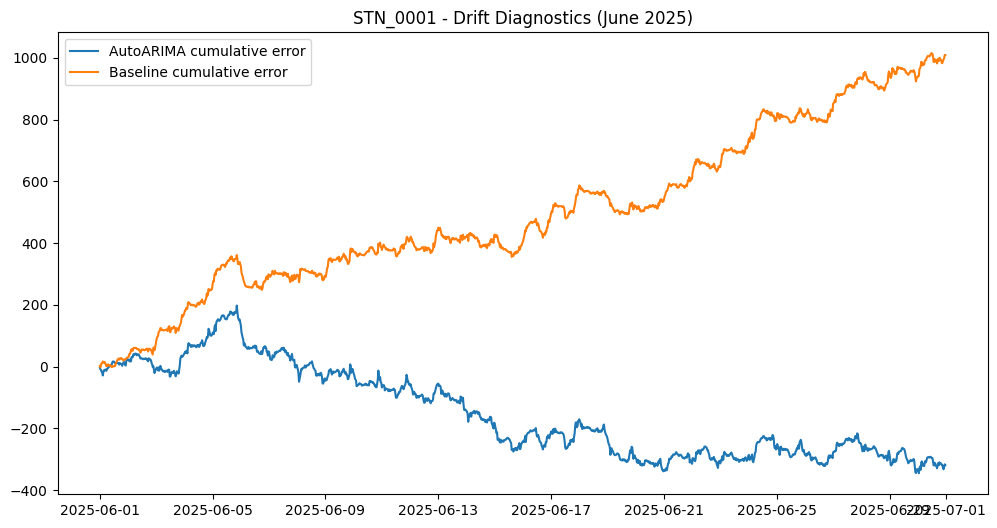

In [56]:
# --- Diagnostics: cumulative error (single block) ---
flows_june['error_net_flow_arima'] = flows_june['net_flow'] - flows_june['pred_net_flow']
flows_june['error_net_flow_baseline'] = flows_june['net_flow'] - flows_june['baseline_net_flow']
flows_june['cumulative_error_arima'] = flows_june['error_net_flow_arima'].cumsum()
flows_june['cumulative_error_baseline'] = flows_june['error_net_flow_baseline'].cumsum()

plt.figure(figsize=(12,6))
plt.plot(flows_june['end_time'], flows_june['cumulative_error_arima'], label='AutoARIMA cumulative error')
plt.plot(flows_june['end_time'], flows_june['cumulative_error_baseline'], label='Baseline cumulative error')
plt.title(f"{station_id} - Drift Diagnostics (June 2025)")
plt.legend()
plt.show()


In [57]:
# --- Inventory and stockout (single calculation) ---
station_capacity = pilot_capacity
initial_bikes = math.floor(0.5 * station_capacity)

flows_june['inventory_arima'] = initial_bikes + flows_june['pred_net_flow'].cumsum()
flows_june['inventory_baseline'] = initial_bikes + flows_june['baseline_net_flow'].cumsum()

flows_june['stockout_arima'] = (flows_june['inventory_arima'] < 0) | (flows_june['inventory_arima'] > station_capacity)
flows_june['stockout_baseline'] = (flows_june['inventory_baseline'] < 0) | (flows_june['inventory_baseline'] > station_capacity)

print("Stockout events (AutoARIMA):", int(flows_june['stockout_arima'].sum()))
print("Stockout events (Baseline):", int(flows_june['stockout_baseline'].sum()))


Stockout events (AutoARIMA): 1437
Stockout events (Baseline): 1425


------------------------------------------------------------------------------------------------------------------------------


AI Help Redo with other TS models

In [58]:
import numpy as np
import pandas as pd
import math
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# --- Single metric definitions ---
def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

# --- Preconditions (assumed) ---
# flows_may, flows_june: DataFrames with columns ['end_time','inflow','outflow']
# sf_in_pred, sf_out_pred: AutoARIMA predictions with columns ['ds', '<model>']
# station_id, pilot_capacity exist

# --- Ensure datetime and sorting ---
flows_may = flows_may.copy().sort_values('end_time').reset_index(drop=True)
flows_june = flows_june.copy().sort_values('end_time').reset_index(drop=True)
flows_may['end_time'] = pd.to_datetime(flows_may['end_time'])
flows_june['end_time'] = pd.to_datetime(flows_june['end_time'])

# --- Helper: hour_of_week feature ---
def add_hour_of_week(df):
    df = df.copy()
    df['hour_of_week'] = (
        df['end_time'].dt.dayofweek * 48 +
        df['end_time'].dt.hour * 2 +
        (df['end_time'].dt.minute // 30)
    )
    return df

flows_may = add_hour_of_week(flows_may)
flows_june = add_hour_of_week(flows_june)

h = len(flows_june)  # forecast horizon

# --- 1) AutoARIMA predictions alignment (assumes you already have sf_in_pred/sf_out_pred) ---
sf_in_pred = sf_in_pred.drop(columns=[c for c in ['unique_id'] if c in sf_in_pred.columns])
sf_out_pred = sf_out_pred.drop(columns=[c for c in ['unique_id'] if c in sf_out_pred.columns])
merged_arima = pd.merge(sf_in_pred, sf_out_pred, on='ds', suffixes=('_in','_out'))

# detect model columns ending with _in/_out
in_col = [c for c in merged_arima.columns if c.endswith('_in') and c != 'ds'][0]
out_col = [c for c in merged_arima.columns if c.endswith('_out') and c != 'ds'][0]
merged_arima = merged_arima.rename(columns={in_col: 'pred_inflow', out_col: 'pred_outflow'})
merged_arima['pred_net_flow'] = merged_arima['pred_inflow'] - merged_arima['pred_outflow']

pred_arima = merged_arima[['ds','pred_inflow','pred_outflow','pred_net_flow']].rename(columns={'ds':'end_time'})
pred_arima = pred_arima.set_index('end_time').reindex(flows_june['end_time']).reset_index()

# --- 2) Regression via numpy.linalg.lstsq (one-hot hour_of_week + linear trend) ---
# Build design matrix for May
X_may = pd.get_dummies(flows_may['hour_of_week'], prefix='h')
X_may['t'] = np.arange(len(X_may))
X_may = X_may.astype(float)
y_in_may = flows_may['inflow'].astype(float).values
y_out_may = flows_may['outflow'].astype(float).values

# Solve OLS with numpy lstsq
beta_in, *_ = np.linalg.lstsq(X_may.values, y_in_may, rcond=None)
beta_out, *_ = np.linalg.lstsq(X_may.values, y_out_may, rcond=None)

# Build June design matrix aligned to training columns
X_june = pd.get_dummies(flows_june['hour_of_week'], prefix='h')
# ensure same columns as X_may (except 't' which we add separately)
X_june = X_june.reindex(columns=[c for c in X_may.columns if c != 't'], fill_value=0)
X_june['t'] = np.arange(len(X_june))
X_june = X_june.astype(float)

pred_reg_in = X_june.values @ beta_in
pred_reg_out = X_june.values @ beta_out

pred_reg = pd.DataFrame({
    'end_time': flows_june['end_time'],
    'pred_inflow': pred_reg_in,
    'pred_outflow': pred_reg_out
})
pred_reg['pred_net_flow'] = pred_reg['pred_inflow'] - pred_reg['pred_outflow']

# --- 3) Exponential Smoothing (Holt-Winters) fit on May and forecast h steps ---
season_length = 48  # daily seasonality at 30-min bins

def hw_forecast(series, h, seasonal_periods=season_length):
    # series: 1D array or pd.Series
    model = ExponentialSmoothing(series, trend='add', seasonal='add',
                                 seasonal_periods=seasonal_periods,
                                 initialization_method='estimated')
    fit = model.fit(optimized=True)
    return fit.forecast(h)

hw_in_fore = hw_forecast(flows_may['inflow'].astype(float).values, h)
hw_out_fore = hw_forecast(flows_may['outflow'].astype(float).values, h)

pred_hw = pd.DataFrame({
    'end_time': flows_june['end_time'],
    'pred_inflow': hw_in_fore,
    'pred_outflow': hw_out_fore
})
pred_hw['pred_net_flow'] = pred_hw['pred_inflow'] - pred_hw['pred_outflow']

# --- 4) Baseline hour-of-week averages from May ---
baseline_inflow = flows_may.groupby('hour_of_week')['inflow'].mean()
baseline_outflow = flows_may.groupby('hour_of_week')['outflow'].mean()

pred_base = pd.DataFrame({
    'end_time': flows_june['end_time'],
    'pred_inflow': flows_june['hour_of_week'].map(baseline_inflow).fillna(0).values,
    'pred_outflow': flows_june['hour_of_week'].map(baseline_outflow).fillna(0).values
})
pred_base['pred_net_flow'] = pred_base['pred_inflow'] - pred_base['pred_outflow']

# --- 5) Compute metrics for each model on aligned rows ---
def compute_metrics(pred_df):
    df = pred_df.set_index('end_time').reindex(flows_june['end_time']).reset_index()
    # ensure numeric columns exist
    for c in ['pred_inflow','pred_outflow','pred_net_flow']:
        if c not in df.columns:
            df[c] = 0.0
    return {
        'MAE_inflow': mae(flows_june['inflow'], df['pred_inflow']),
        'MAPE_inflow': mape(flows_june['inflow'], df['pred_inflow']),
        'MAE_outflow': mae(flows_june['outflow'], df['pred_outflow']),
        'MAPE_outflow': mape(flows_june['outflow'], df['pred_outflow']),
        'MAE_net_flow': mae(flows_june['net_flow'], df['pred_net_flow']),
        'MAPE_net_flow': mape(flows_june['net_flow'], df['pred_net_flow']),
        'pred_aligned': df  # return aligned predictions for optional diagnostics
    }

metrics = {}
metrics['AutoARIMA'] = compute_metrics(pred_arima)
metrics['Regression'] = compute_metrics(pred_reg)
metrics['ExpSmoothing'] = compute_metrics(pred_hw)
metrics['Baseline'] = compute_metrics(pred_base)

# --- 6) Build a compact comparison DataFrame and print ---
rows = []
for name, res in metrics.items():
    rows.append({
        'model': name,
        'MAE_net_flow': res['MAE_net_flow'],
        'MAPE_net_flow': res['MAPE_net_flow'],
        'MAE_inflow': res['MAE_inflow'],
        'MAE_outflow': res['MAE_outflow']
    })
comp_df = pd.DataFrame(rows).sort_values('MAE_net_flow').reset_index(drop=True)
print(comp_df.to_string(index=False))

# --- 7) Optional: attach aligned predictions for one model to flows_june for plotting ---
# Example: attach AutoARIMA aligned preds
flows_june = flows_june.merge(metrics['AutoARIMA']['pred_aligned'][['end_time','pred_inflow','pred_outflow','pred_net_flow']],
                              on='end_time', how='left', suffixes=('','_arima'))
flows_june = flows_june.rename(columns={
    'pred_inflow': 'arima_inflow',
    'pred_outflow': 'arima_outflow',
    'pred_net_flow': 'arima_net_flow'
})

       model  MAE_net_flow  MAPE_net_flow  MAE_inflow  MAE_outflow
    Baseline      4.601597     245.703522    6.725590     5.982674
  Regression      4.620903     246.978379    6.913379     6.058841
   AutoARIMA      5.199317     298.294098    6.202804     5.836717
ExpSmoothing      6.709448     512.341520    9.018994    13.475374


Stockout summaries (per model):

**AutoARIMA**
  Total stockout bins: 468
  Total stockout minutes: 14040
  First stockout time: 2025-06-01 01:30:00
  Intervals (start -> end, minutes, reason):
    2025-06-01 01:30:00 -> 2025-06-01 02:30:00, 90 min, full
    2025-06-01 04:00:00 -> 2025-06-01 04:00:00, 30 min, full
    2025-06-01 05:00:00 -> 2025-06-01 05:30:00, 60 min, full
    2025-06-01 07:00:00 -> 2025-06-01 07:00:00, 30 min, full
    2025-06-01 22:00:00 -> 2025-06-01 22:00:00, 30 min, full

**Regression**
  Total stockout bins: 551
  Total stockout minutes: 16530
  First stockout time: 2025-06-01 04:30:00
  Intervals (start -> end, minutes, reason):
    2025-06-01 04:30:00 -> 2025-06-01 09:00:00, 300 min, full
    2025-06-01 16:30:00 -> 2025-06-01 19:00:00, 180 min, empty
    2025-06-02 01:30:00 -> 2025-06-02 05:30:00, 270 min, full
    2025-06-02 15:30:00 -> 2025-06-02 16:00:00, 60 min, empty
    2025-06-02 18:00:00 -> 2025-06-02 19:00:00, 90 min, empty

**ExpSmoothing**
  Total s

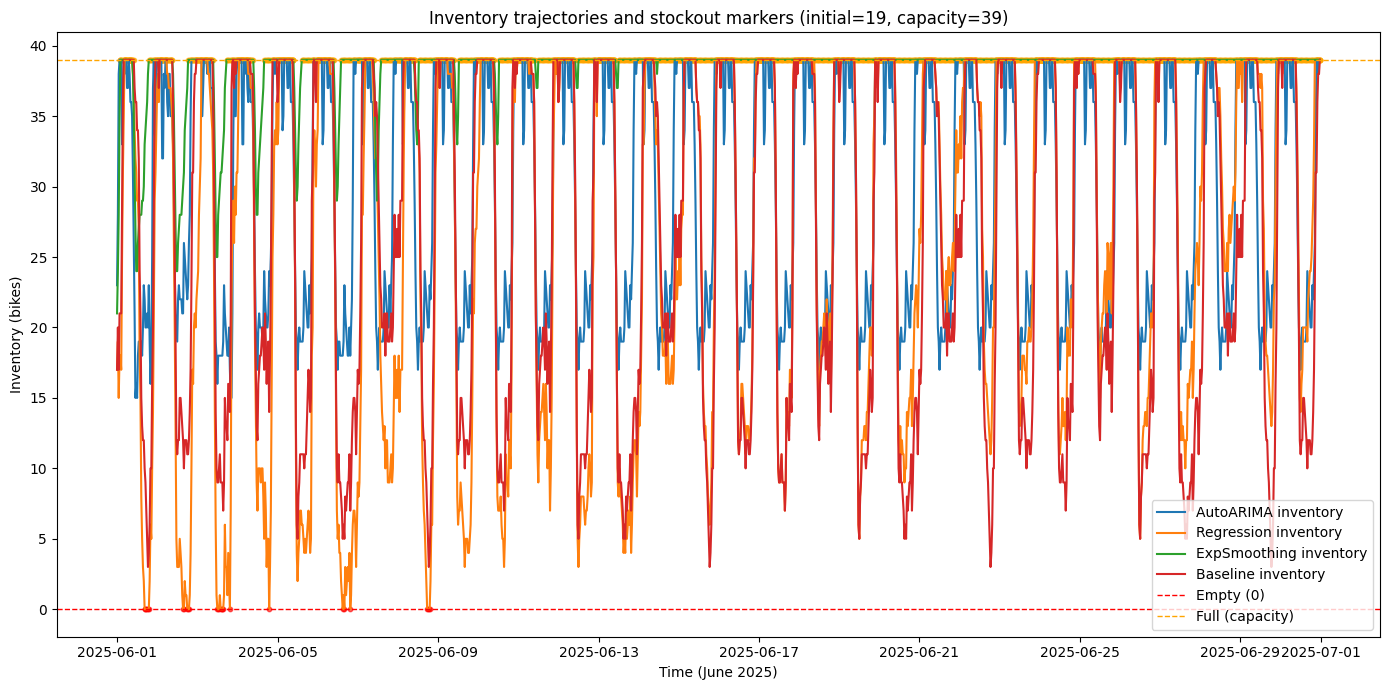

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- Parameters (set these to your values) ---
# station_capacity = pilot_capacity  # integer
# initial_bikes = math.floor(0.5 * station_capacity)  # integer

# --- Helper: ensure predictions are aligned to flows_june end_time ---
def align_preds(pred_df, flows_june):
    df = pred_df.copy()
    df['end_time'] = pd.to_datetime(df['end_time'])
    aligned = df.set_index('end_time').reindex(flows_june['end_time']).reset_index()
    # ensure columns exist
    for c in ['pred_inflow','pred_outflow','pred_net_flow']:
        if c not in aligned.columns:
            aligned[c] = 0.0
    return aligned

pred_arima_aligned = align_preds(pred_arima, flows_june)
pred_reg_aligned   = align_preds(pred_reg, flows_june)
pred_hw_aligned    = align_preds(pred_hw, flows_june)
pred_base_aligned  = align_preds(pred_base, flows_june)

models = {
    'AutoARIMA': pred_arima_aligned,
    'Regression': pred_reg_aligned,
    'ExpSmoothing': pred_hw_aligned,
    'Baseline': pred_base_aligned
}

# --- Simulation function ---
def simulate_inventory(pred_df, initial_bikes, capacity, round_flows=True):
    """
    pred_df: DataFrame with columns ['end_time','pred_net_flow'] aligned to flows_june
    initial_bikes: int
    capacity: int
    round_flows: whether to round predicted net flows to nearest integer
    Returns: DataFrame with inventory, stockout flags, and stockout intervals summary
    """
    df = pred_df[['end_time','pred_inflow','pred_outflow','pred_net_flow']].copy()
    df['end_time'] = pd.to_datetime(df['end_time'])
    # Round predicted net flow to integer to simulate discrete bikes
    if round_flows:
        df['pred_net_flow_int'] = np.round(df['pred_net_flow']).astype(int)
    else:
        df['pred_net_flow_int'] = df['pred_net_flow'].astype(float)
    # cumulative inventory (before clipping)
    df['inventory_raw'] = initial_bikes + df['pred_net_flow_int'].cumsum()
    # For simulation of real system, clip inventory to [0, capacity] at each step
    inv = []
    current = initial_bikes
    for delta in df['pred_net_flow_int'].values:
        current = current + int(delta)
        # record unclipped inventory for diagnostics, but also compute clipped inventory
        inv.append(current)
        # clip for next step (simulate physical limits)
        if current < 0:
            current = 0
        elif current > capacity:
            current = capacity
    df['inventory_unclipped'] = inv
    # Also compute clipped inventory series (what would be observed)
    df['inventory_clipped'] = np.clip(df['inventory_unclipped'], 0, capacity)
    # Stockout flags: either empty (<=0) or full (>=capacity)
    df['is_empty'] = df['inventory_clipped'] <= 0
    df['is_full']  = df['inventory_clipped'] >= capacity
    df['is_stockout'] = df['is_empty'] | df['is_full']
    # Summarize stockout intervals (start, end, duration in minutes and bins)
    df['stockout_group'] = (df['is_stockout'] != df['is_stockout'].shift(1)).cumsum()
    intervals = []
    for gid, g in df.groupby('stockout_group'):
        if not g['is_stockout'].iloc[0]:
            continue
        start = g['end_time'].iloc[0]
        end = g['end_time'].iloc[-1]
        bins = len(g)
        minutes = bins * 30
        reason = 'full' if g['is_full'].all() else ('empty' if g['is_empty'].all() else 'mixed')
        intervals.append({'start': start, 'end': end, 'bins': bins, 'minutes': minutes, 'reason': reason})
    summary = {
        'total_stockout_bins': int(df['is_stockout'].sum()),
        'total_stockout_minutes': int(df['is_stockout'].sum() * 30),
        'first_stockout_time': intervals[0]['start'] if intervals else None,
        'stockout_intervals': intervals
    }
    return df, summary

# --- Run simulation for each model ---
sim_results = {}
for name, pred in models.items():
    sim_df, sim_summary = simulate_inventory(pred, initial_bikes, station_capacity, round_flows=True)
    sim_results[name] = {'df': sim_df, 'summary': sim_summary}

# --- Print concise stockout summaries ---
print("Stockout summaries (per model):")
for name, res in sim_results.items():
    s = res['summary']
    print(f"\n**{name}**")
    print("  Total stockout bins:", s['total_stockout_bins'])
    print("  Total stockout minutes:", s['total_stockout_minutes'])
    print("  First stockout time:", s['first_stockout_time'])
    if s['stockout_intervals']:
        print("  Intervals (start -> end, minutes, reason):")
        for it in s['stockout_intervals'][:5]:
            print(f"    {it['start']} -> {it['end']}, {it['minutes']} min, {it['reason']}")
    else:
        print("  No stockout intervals detected.")

# --- Plot inventory trajectories and highlight stockout intervals ---
plt.figure(figsize=(14,7))
colors = {'AutoARIMA':'C0','Regression':'C1','ExpSmoothing':'C2','Baseline':'C3'}
for name, res in sim_results.items():
    df = res['df']
    plt.plot(df['end_time'], df['inventory_clipped'], label=f"{name} inventory", color=colors.get(name,'k'))
    # highlight empty intervals (red) and full intervals (orange)
    empty_intervals = df[df['is_empty']]
    full_intervals = df[df['is_full']]
    if not empty_intervals.empty:
        plt.scatter(empty_intervals['end_time'], empty_intervals['inventory_clipped'], color='red', s=10, alpha=0.6)
    if not full_intervals.empty:
        plt.scatter(full_intervals['end_time'], full_intervals['inventory_clipped'], color='orange', s=10, alpha=0.6)

# horizontal lines for 0 and capacity
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Empty (0)')
plt.axhline(station_capacity, color='orange', linestyle='--', linewidth=1, label='Full (capacity)')

plt.xlabel('Time (June 2025)')
plt.ylabel('Inventory (bikes)')
plt.title(f"Inventory trajectories and stockout markers (initial={initial_bikes}, capacity={station_capacity})")
plt.legend()
plt.tight_layout()
plt.show()

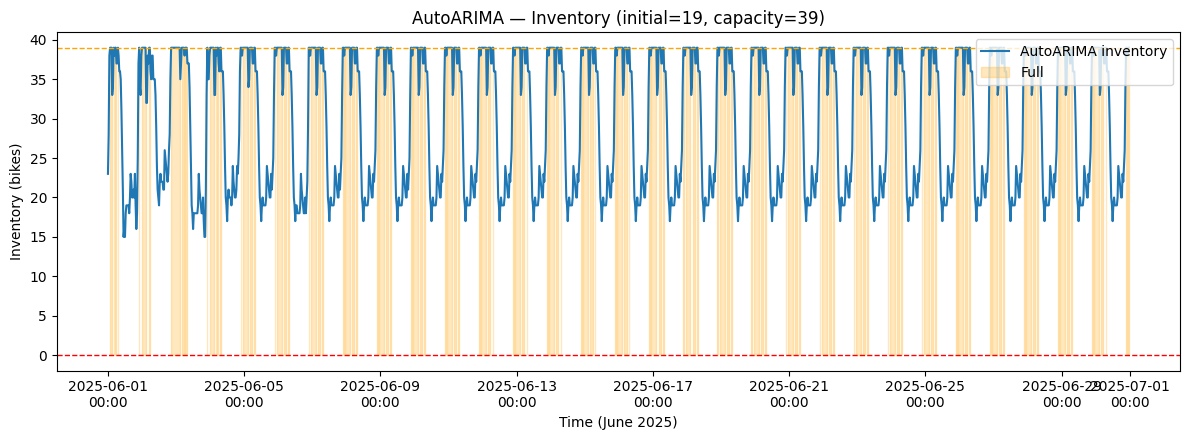

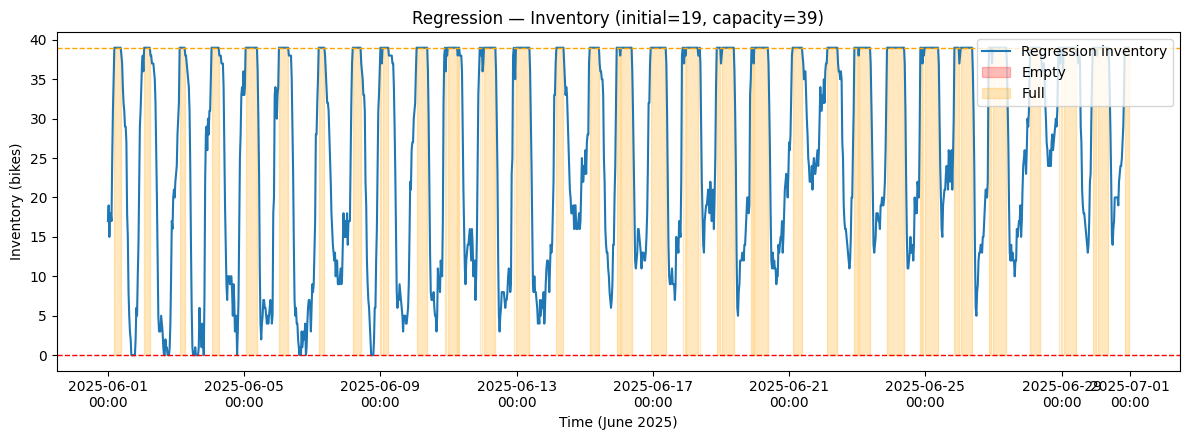

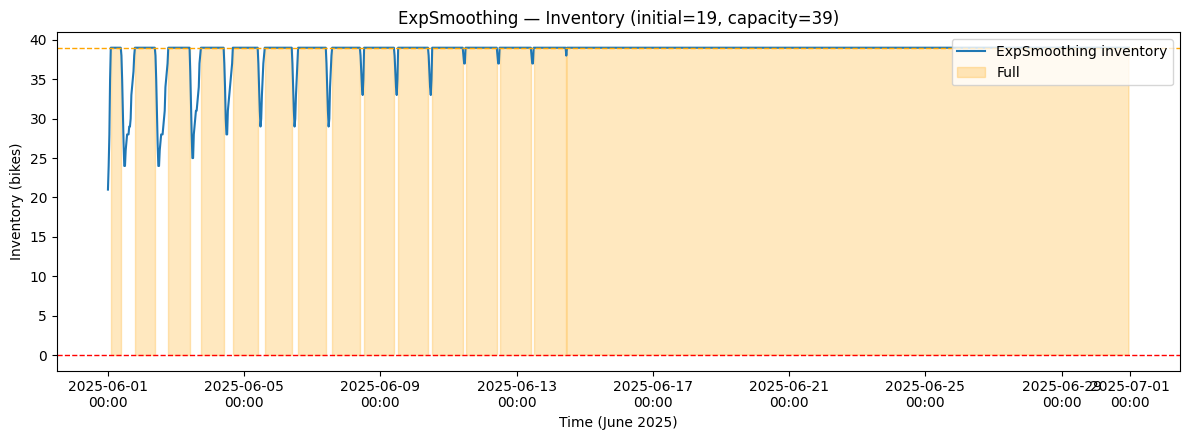

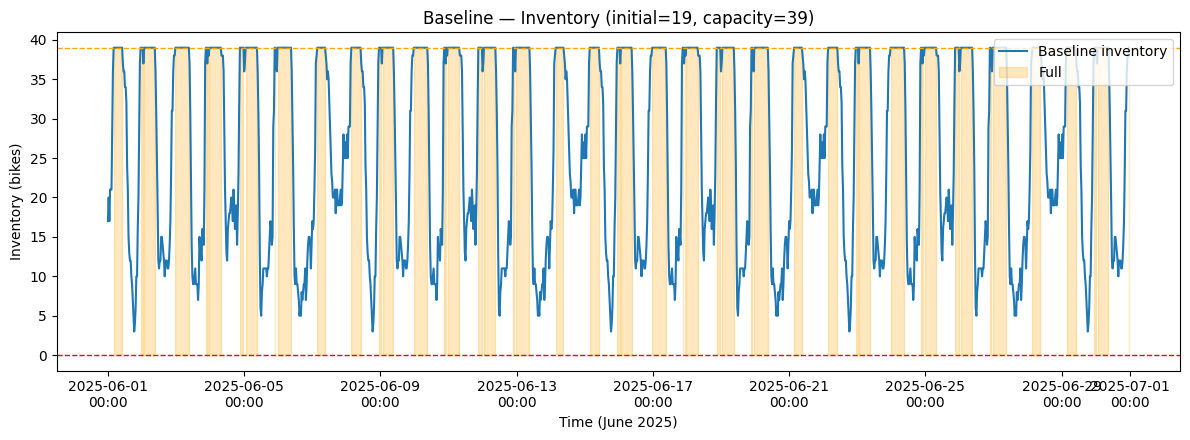

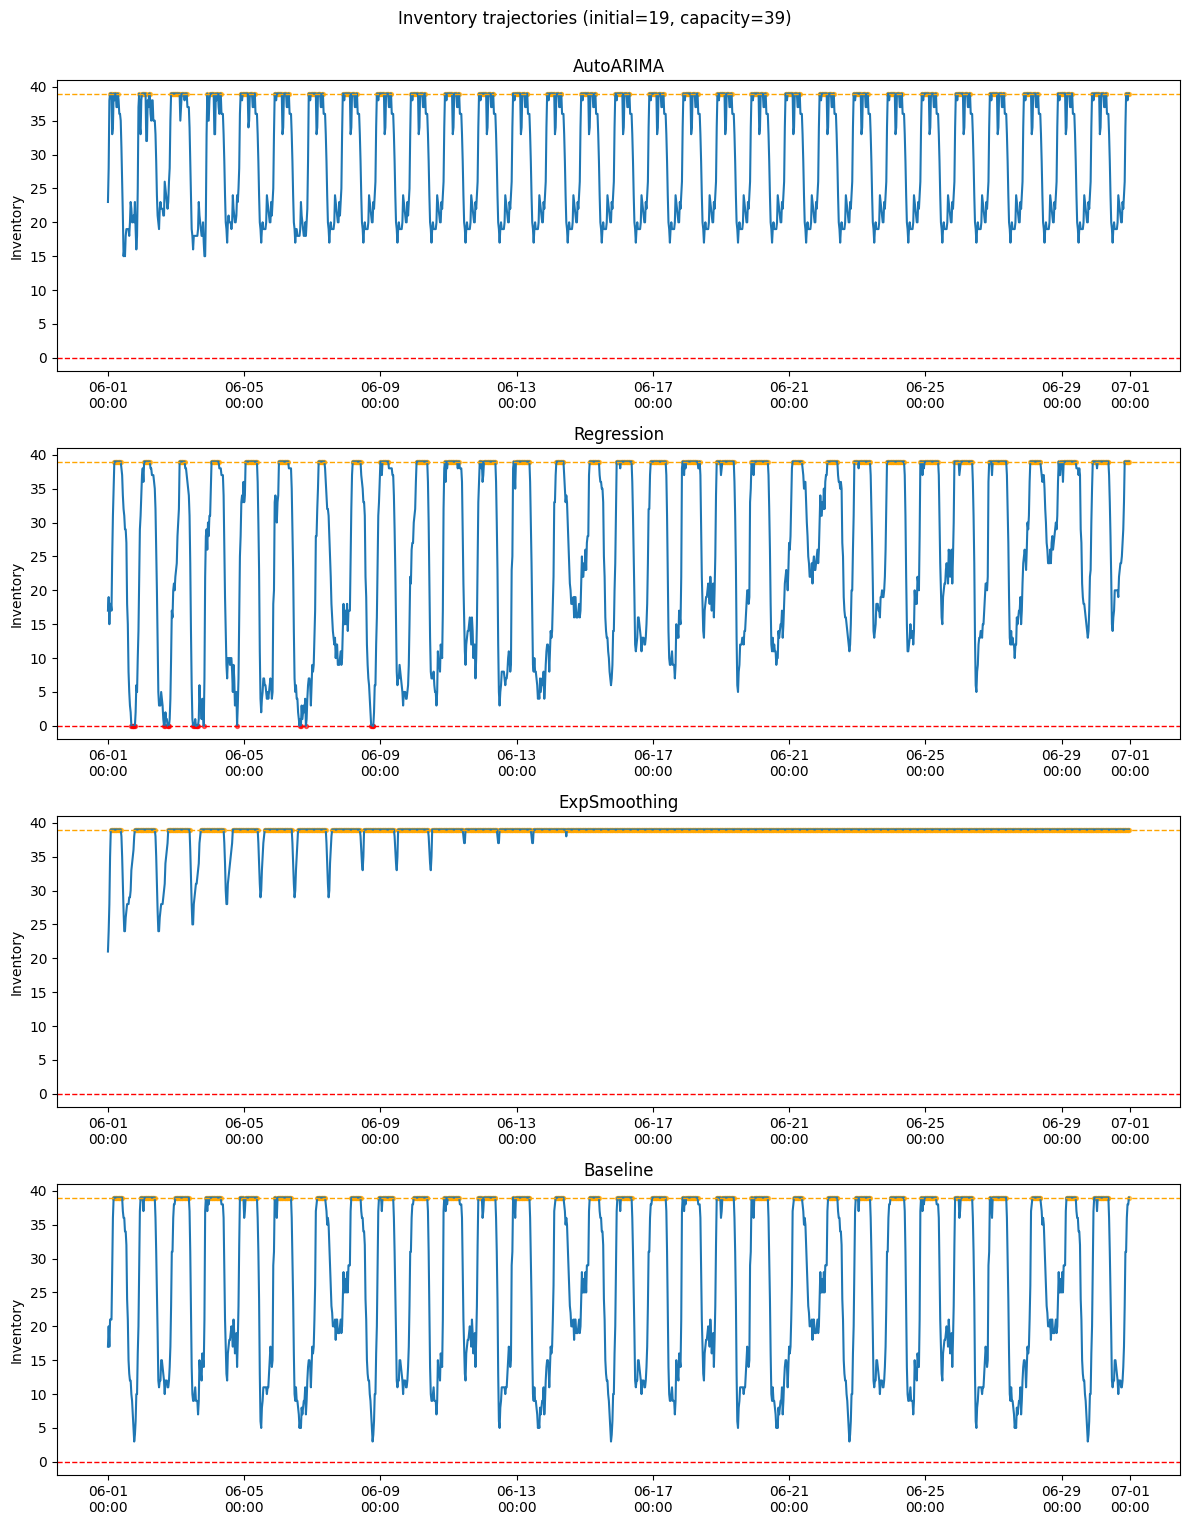

In [61]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# sim_results: dict from previous simulation step
# station_capacity, initial_bikes must be defined

# Option A: individual figures (one window per model)
for name, res in sim_results.items():
    df = res['df'].copy()
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(df['end_time'], df['inventory_clipped'], label=f"{name} inventory", color='C0')
    # shaded empty intervals
    empty = df['is_empty']
    if empty.any():
        ax.fill_between(df['end_time'], 0, df['inventory_clipped'],
                        where=empty, color='red', alpha=0.25, step='mid', label='Empty')
    # shaded full intervals
    full = df['is_full']
    if full.any():
        ax.fill_between(df['end_time'], 0, df['inventory_clipped'],
                        where=full, color='orange', alpha=0.25, step='mid', label='Full')
    # horizontal lines
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.axhline(station_capacity, color='orange', linestyle='--', linewidth=1)
    # formatting
    ax.set_title(f"{name} — Inventory (initial={initial_bikes}, capacity={station_capacity})")
    ax.set_xlabel("Time (June 2025)")
    ax.set_ylabel("Inventory (bikes)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Option B: grid of separate subplots (compact)
model_names = list(sim_results.keys())
n = len(model_names)
cols = 1 if n <= 4 else 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
for ax, name in zip(axes.flatten(), model_names):
    df = sim_results[name]['df']
    ax.plot(df['end_time'], df['inventory_clipped'], color='C0')
    # highlight empty/full with scatter for clarity in compact grid
    ax.scatter(df.loc[df['is_empty'],'end_time'], df.loc[df['is_empty'],'inventory_clipped'],
               color='red', s=8, alpha=0.6)
    ax.scatter(df.loc[df['is_full'],'end_time'], df.loc[df['is_full'],'inventory_clipped'],
               color='orange', s=8, alpha=0.6)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.axhline(station_capacity, color='orange', linestyle='--', linewidth=1)
    ax.set_title(f"{name}")
    ax.set_ylabel("Inventory")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
# hide any unused axes
for ax in axes.flatten()[len(model_names):]:
    ax.set_visible(False)
plt.suptitle(f"Inventory trajectories (initial={initial_bikes}, capacity={station_capacity})", y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------

Directional Check with Actuals

June 2025 actual inventory summary for station: STN_0002
  Total 30-min bins in June: 1440
  Stockout bins (empty or full): 1412
  Stockout minutes: 42360
  First stockout time (if any): 2025-06-01 14:00:00


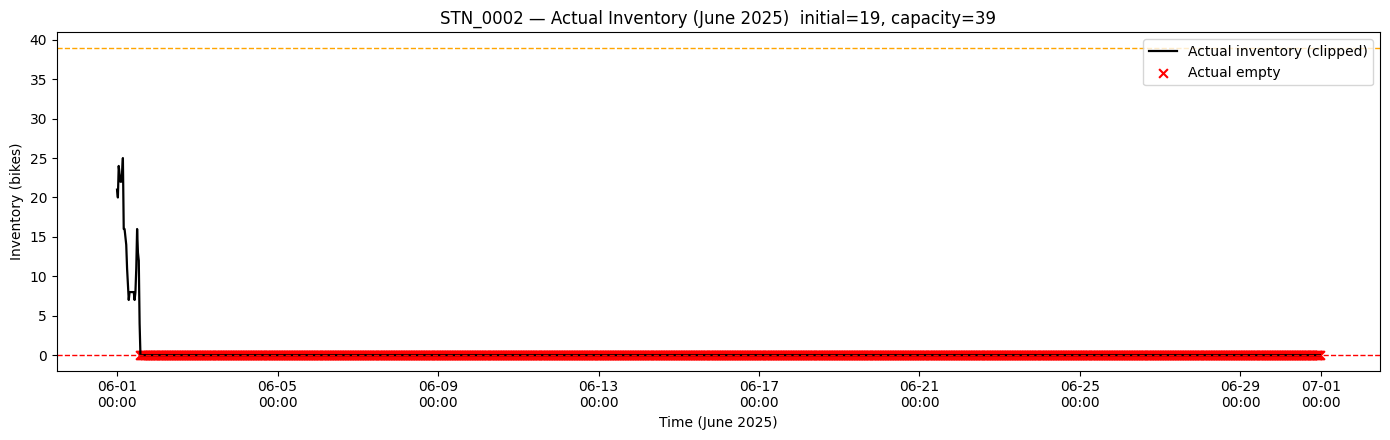

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
from pathlib import Path

# Parameters you must set
station_id = "STN_0002"
station_capacity = pilot_capacity   # ensure pilot_capacity is defined
initial_bikes = math.floor(0.5 * station_capacity)

# Load parquet (adjust path if needed)
rides_path = Path(r"C:/Users/Daniel Loh/Documents/NUS-ISS_EBAC/BDA/BDA Project Module/silver/ride_year=2025")
rides_df = pd.read_parquet(rides_path, engine="pyarrow")

# Convert epoch ms to datetimes (explicit unit)
if 'start_time_ms' in rides_df.columns:
    rides_df['start_time'] = pd.to_datetime(rides_df['start_time_ms'], unit='ms')
if 'end_time_ms' in rides_df.columns:
    rides_df['end_time']   = pd.to_datetime(rides_df['end_time_ms'], unit='ms')
else:
    raise ValueError("rides_df missing 'end_time_ms'")

# --- Aggregate: ensure both group results use the same time column name before merging ---
# Outflow: trips that start at the station (group by start_time), rename to 'end_time' for merge
outflow = (
    rides_df[rides_df['start_canonical_station_id'] == station_id]
    .groupby(pd.Grouper(key='start_time', freq='30min'))
    .size()
    .reset_index(name='outflow')
)
outflow = outflow.rename(columns={'start_time': 'end_time'})

# Inflow: trips that end at the station (group by end_time)
inflow = (
    rides_df[rides_df['end_canonical_station_id'] == station_id]
    .groupby(pd.Grouper(key='end_time', freq='30min'))
    .size()
    .reset_index(name='inflow')
)

# Merge on the unified 'end_time' column
flows = pd.merge(inflow, outflow, on='end_time', how='outer').fillna(0)
flows = flows.sort_values('end_time').reset_index(drop=True)
flows['inflow'] = flows['inflow'].astype(int)
flows['outflow'] = flows['outflow'].astype(int)

# --- Restrict to June 2025 and ensure full 30-min coverage ---
start_june = pd.Timestamp("2025-06-01 00:00:00")
end_june   = pd.Timestamp("2025-06-30 23:30:00")
time_index = pd.date_range(start=start_june, end=end_june, freq='30min')

flows_june = flows.set_index('end_time').reindex(time_index).fillna(0).reset_index().rename(columns={'index':'end_time'})
flows_june['inflow'] = flows_june['inflow'].astype(int)
flows_june['outflow'] = flows_june['outflow'].astype(int)

# --- Compute net flow and actual inventory for June ---
flows_june['net_flow'] = flows_june['inflow'] - flows_june['outflow']
flows_june['net_flow_int'] = np.round(flows_june['net_flow']).astype(int)
flows_june['inventory_unclipped'] = initial_bikes + flows_june['net_flow_int'].cumsum()
flows_june['inventory_clipped'] = np.clip(flows_june['inventory_unclipped'], 0, station_capacity)
flows_june['is_empty'] = flows_june['inventory_clipped'] <= 0
flows_june['is_full']  = flows_june['inventory_clipped'] >= station_capacity
flows_june['is_stockout'] = flows_june['is_empty'] | flows_june['is_full']

# --- Quick summary ---
total_bins = len(flows_june)
stockout_bins = int(flows_june['is_stockout'].sum())
stockout_minutes = stockout_bins * 30
first_stockout = flows_june.loc[flows_june['is_stockout'], 'end_time'].iloc[0] if stockout_bins > 0 else None

print("June 2025 actual inventory summary for station:", station_id)
print("  Total 30-min bins in June:", total_bins)
print("  Stockout bins (empty or full):", stockout_bins)
print("  Stockout minutes:", stockout_minutes)
print("  First stockout time (if any):", first_stockout)

# --- Plot actual inventory for June ---
plt.figure(figsize=(14,4.5))
plt.plot(flows_june['end_time'], flows_june['inventory_clipped'], color='black', linewidth=1.6, label='Actual inventory (clipped)')
empty = flows_june[flows_june['is_empty']]
full  = flows_june[flows_june['is_full']]
if not empty.empty:
    plt.scatter(empty['end_time'], empty['inventory_clipped'], color='red', s=40, marker='x', label='Actual empty')
if not full.empty:
    plt.scatter(full['end_time'], full['inventory_clipped'], color='orange', s=40, marker='x', label='Actual full')

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.axhline(station_capacity, color='orange', linestyle='--', linewidth=1)
plt.title(f"{station_id} — Actual Inventory (June 2025)  initial={initial_bikes}, capacity={station_capacity}")
plt.xlabel("Time (June 2025)")
plt.ylabel("Inventory (bikes)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

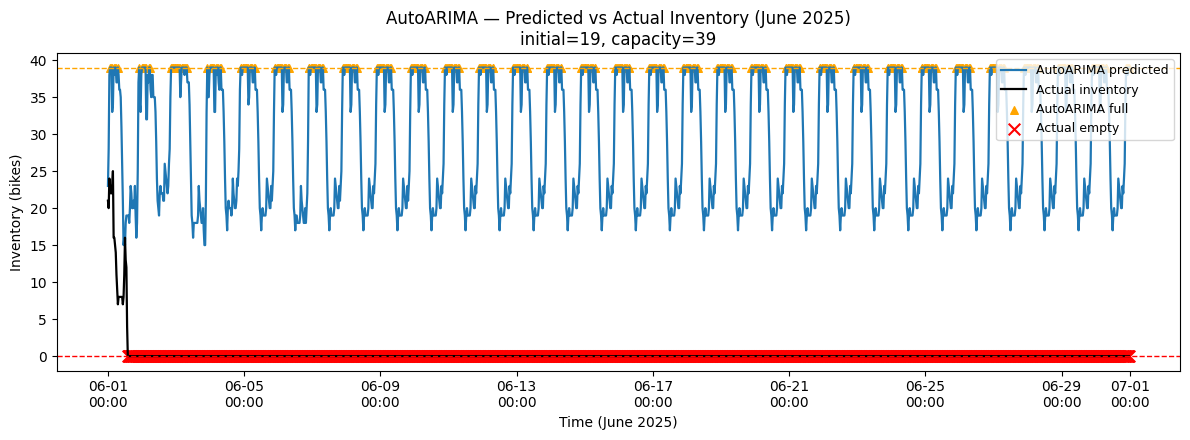

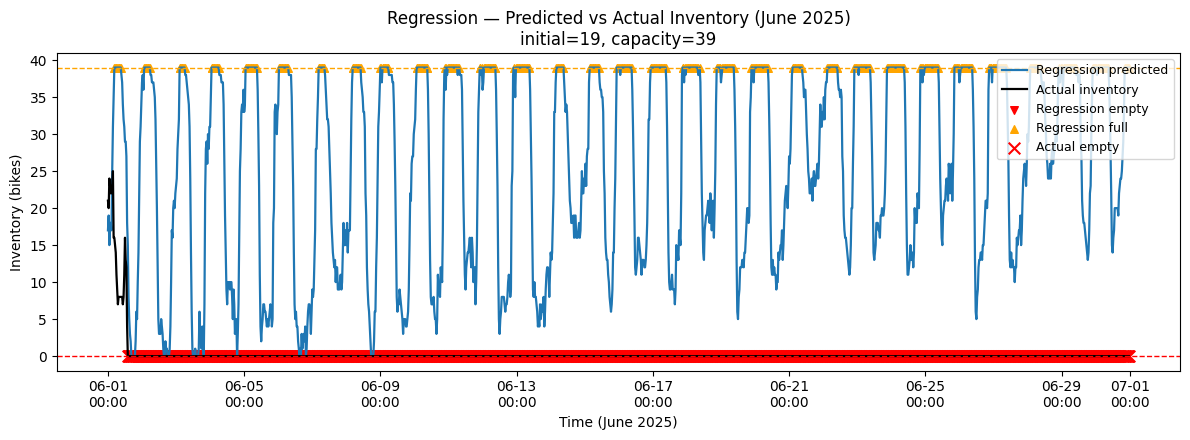

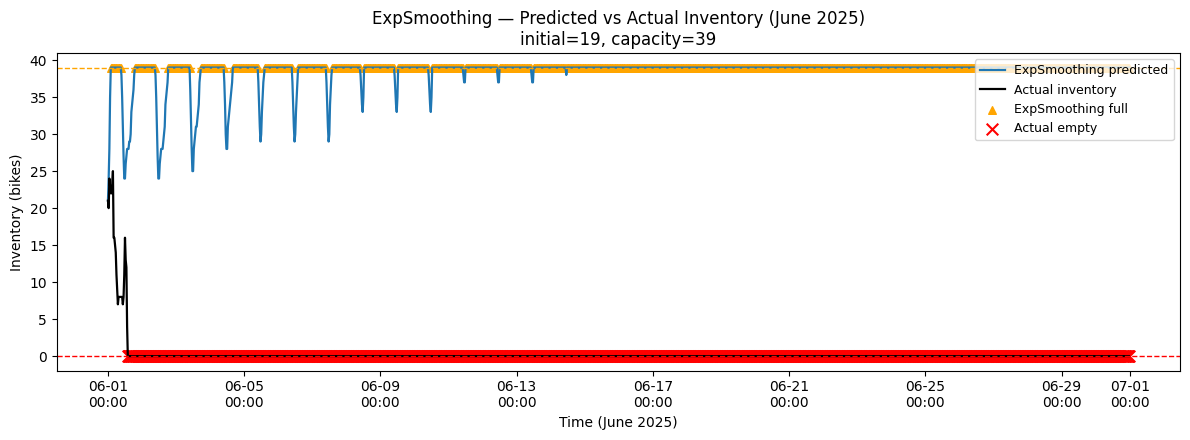

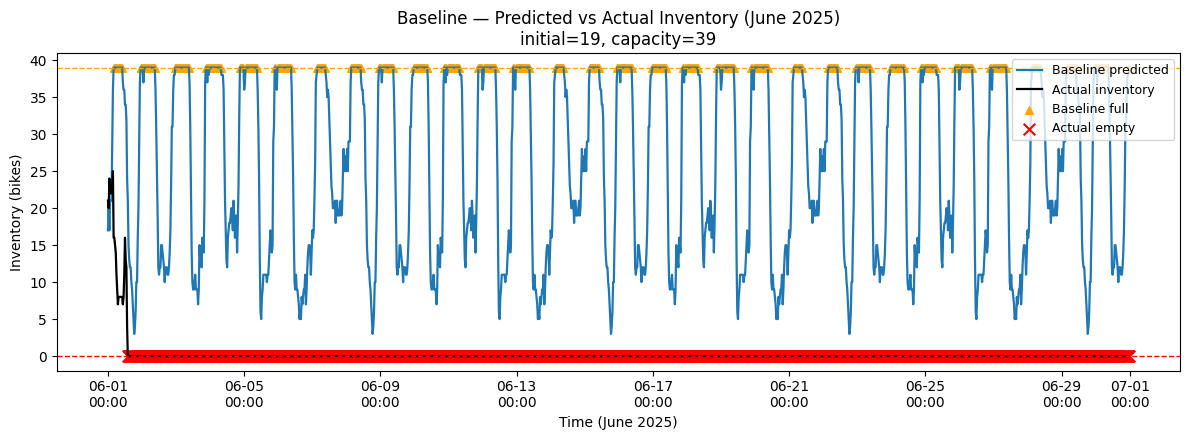

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Preconditions (must exist in your notebook) ---
# flows_june: DataFrame with 'end_time' (datetime) and 'inventory_clipped' (actual)
# pred_arima, pred_reg, pred_hw, pred_base: DataFrames with 'end_time' and 'pred_net_flow' (and optionally pred_inflow/outflow)
# station_capacity: int
# initial_bikes: int

# Quick checks
for name in ['flows_june', 'pred_arima', 'pred_reg', 'pred_hw', 'pred_base']:
    if name not in globals():
        raise ValueError(f"Required variable not found: {name}")

# Ensure flows_june has datetime end_time and actual inventory
flows_june = flows_june.copy().sort_values('end_time').reset_index(drop=True)
flows_june['end_time'] = pd.to_datetime(flows_june['end_time'])
if 'inventory_clipped' not in flows_june.columns:
    raise ValueError("flows_june must contain 'inventory_clipped' (actual inventory)")

# Helper: align predictions to flows_june times and ensure required columns
def align_preds(pred_df, flows_june):
    df = pred_df.copy()
    df['end_time'] = pd.to_datetime(df['end_time'])
    df = df.set_index('end_time').reindex(flows_june['end_time']).reset_index()
    # ensure numeric prediction columns exist
    if 'pred_net_flow' not in df.columns:
        # try to compute from inflow/outflow if present
        if 'pred_inflow' in df.columns and 'pred_outflow' in df.columns:
            df['pred_net_flow'] = df['pred_inflow'].fillna(0) - df['pred_outflow'].fillna(0)
        else:
            df['pred_net_flow'] = 0.0
    for c in ['pred_inflow','pred_outflow']:
        if c not in df.columns:
            df[c] = 0.0
    return df

pred_arima_aligned = align_preds(pred_arima, flows_june)
pred_reg_aligned   = align_preds(pred_reg, flows_june)
pred_hw_aligned    = align_preds(pred_hw, flows_june)
pred_base_aligned  = align_preds(pred_base, flows_june)

models = {
    'AutoARIMA': pred_arima_aligned,
    'Regression': pred_reg_aligned,
    'ExpSmoothing': pred_hw_aligned,
    'Baseline': pred_base_aligned
}

# Inventory simulation from predicted net flow (discrete bikes)
def simulate_inventory_from_pred(pred_df, initial_bikes, capacity, round_flows=True):
    df = pred_df[['end_time','pred_net_flow','pred_inflow','pred_outflow']].copy()
    df['end_time'] = pd.to_datetime(df['end_time'])
    if round_flows:
        df['pred_net_flow_int'] = np.round(df['pred_net_flow'].astype(float)).astype(int)
    else:
        df['pred_net_flow_int'] = df['pred_net_flow'].astype(float)
    # stepwise simulation so clipping affects subsequent steps
    inv_unclipped = []
    current = initial_bikes
    for delta in df['pred_net_flow_int'].values:
        current = current + int(delta)
        inv_unclipped.append(current)
        # clip for next step
        if current < 0:
            current = 0
        elif current > capacity:
            current = capacity
    df['inventory_unclipped'] = inv_unclipped
    df['inventory_clipped'] = np.clip(df['inventory_unclipped'], 0, capacity)
    df['is_empty'] = df['inventory_clipped'] <= 0
    df['is_full']  = df['inventory_clipped'] >= capacity
    return df

# --- Plot one figure per model: predicted inventory vs actual inventory ---
for name, pred in models.items():
    pred_sim = simulate_inventory_from_pred(pred, initial_bikes, station_capacity, round_flows=True)
    # ensure alignment
    pred_sim = pred_sim.set_index('end_time').reindex(flows_june['end_time']).reset_index()

    fig, ax = plt.subplots(figsize=(12, 4.5))
    # predicted inventory
    ax.plot(pred_sim['end_time'], pred_sim['inventory_clipped'], label=f"{name} predicted", color='C0', linewidth=1.6)
    # actual inventory
    ax.plot(flows_june['end_time'], flows_june['inventory_clipped'], label='Actual inventory', color='black', linewidth=1.6)

    # predicted stockout markers
    if pred_sim['is_empty'].any():
        ax.scatter(pred_sim.loc[pred_sim['is_empty'],'end_time'], pred_sim.loc[pred_sim['is_empty'],'inventory_clipped'],
                   color='red', s=30, marker='v', label=f"{name} empty")
    if pred_sim['is_full'].any():
        ax.scatter(pred_sim.loc[pred_sim['is_full'],'end_time'], pred_sim.loc[pred_sim['is_full'],'inventory_clipped'],
                   color='orange', s=30, marker='^', label=f"{name} full")

    # actual stockout markers (larger and distinct)
    actual_empty = flows_june['inventory_clipped'] <= 0
    actual_full  = flows_june['inventory_clipped'] >= station_capacity
    if actual_empty.any():
        ax.scatter(flows_june.loc[actual_empty,'end_time'], flows_june.loc[actual_empty,'inventory_clipped'],
                   color='red', s=70, marker='x', label='Actual empty')
    if actual_full.any():
        ax.scatter(flows_june.loc[actual_full,'end_time'], flows_june.loc[actual_full,'inventory_clipped'],
                   color='orange', s=70, marker='x', label='Actual full')

    # capacity lines
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.axhline(station_capacity, color='orange', linestyle='--', linewidth=1)

    # legend dedupe
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)

    ax.set_title(f"{name} — Predicted vs Actual Inventory (June 2025)\ninitial={initial_bikes}, capacity={station_capacity}")
    ax.set_xlabel("Time (June 2025)")
    ax.set_ylabel("Inventory (bikes)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
    plt.tight_layout()
    plt.show()

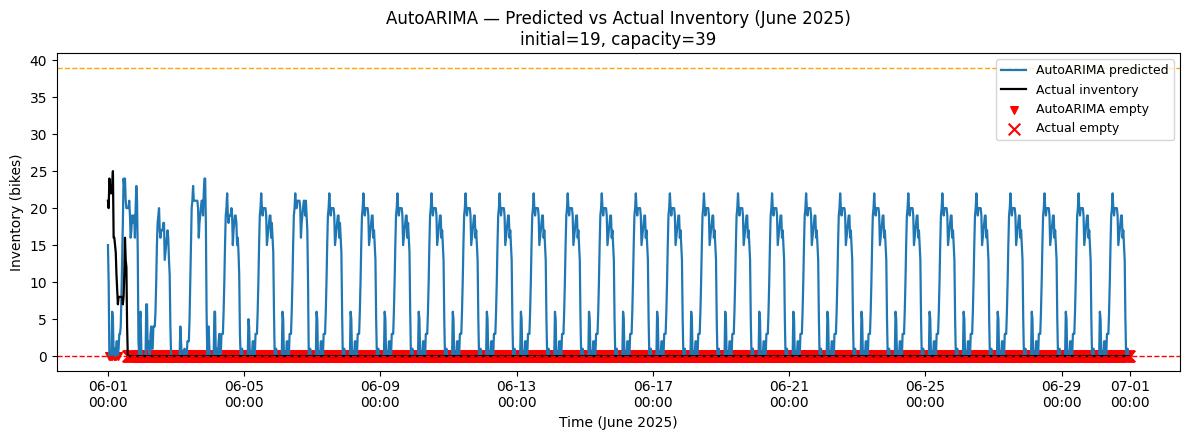


AutoARIMA diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.0007544326171097882, 'pred_mean_after_fix': -1.9350882834493603, 'actual_mean': -1.2159722222222222, 'flipped_sign': True}


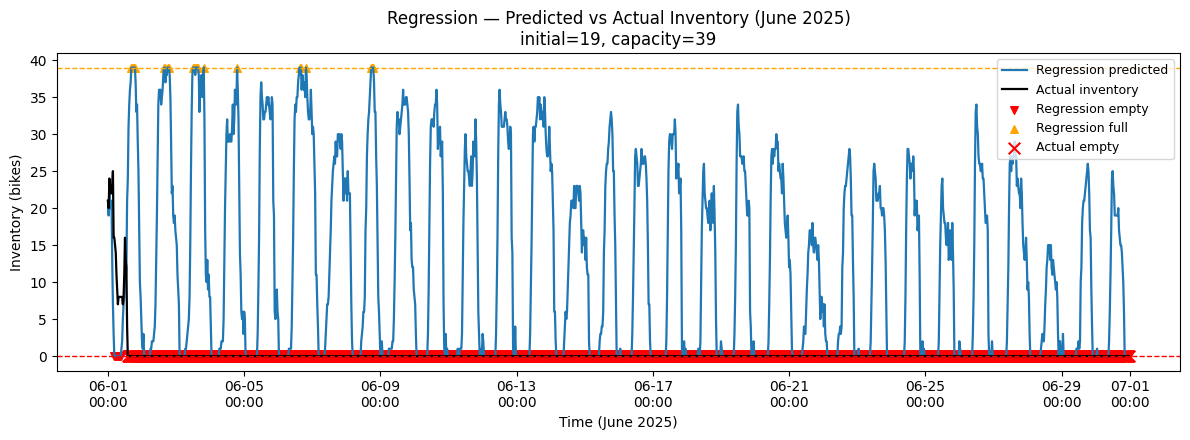


Regression diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.024605222301719295, 'pred_mean_after_fix': -0.9939107142872454, 'actual_mean': -1.2159722222222222, 'flipped_sign': True}


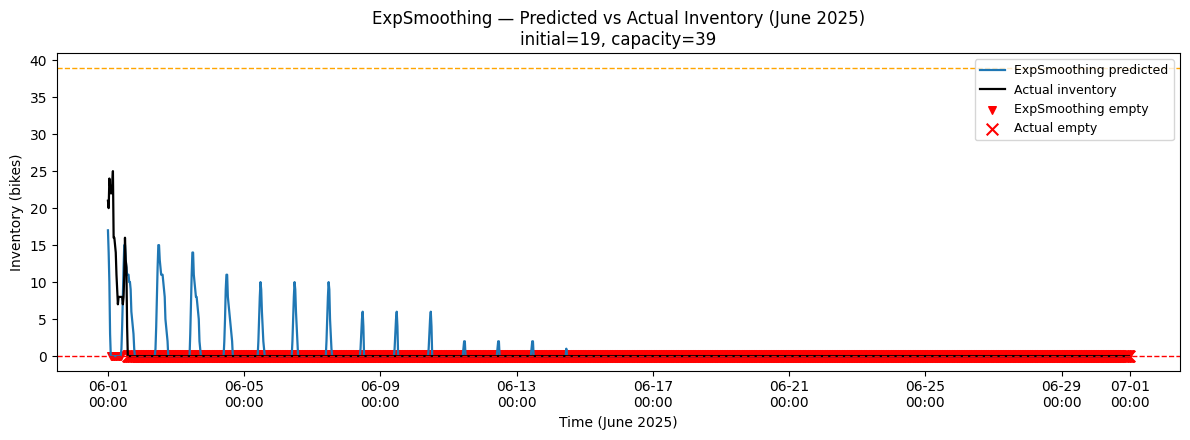


ExpSmoothing diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.024408848401056043, 'pred_mean_after_fix': -6.434879806654658, 'actual_mean': -1.2159722222222222, 'flipped_sign': True}


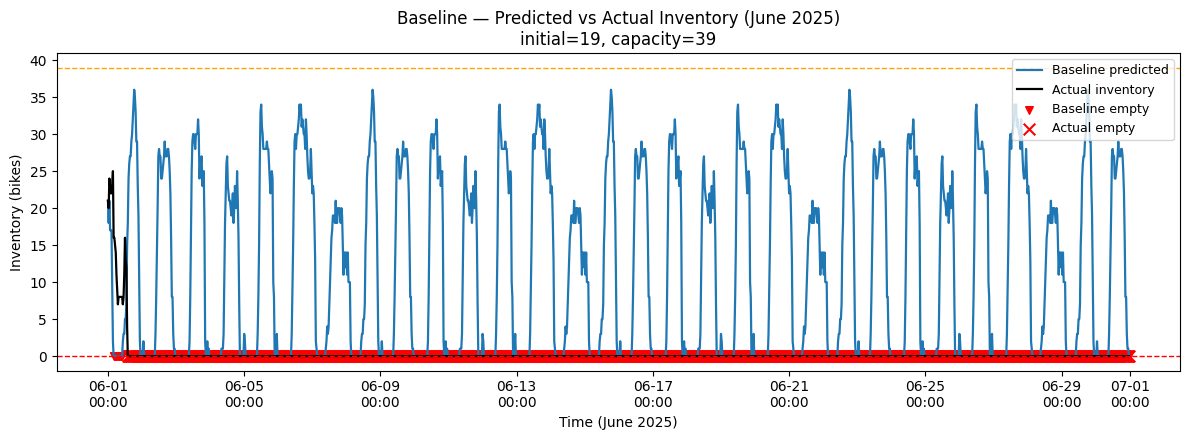


Baseline diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.02259630306268301, 'pred_mean_after_fix': -1.0133333333333334, 'actual_mean': -1.2159722222222222, 'flipped_sign': True}


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Preconditions (unchanged) ---
# flows_june, pred_arima, pred_reg, pred_hw, pred_base, station_capacity, initial_bikes

# --- Helper to ensure pred_net_flow exists and is numeric ---
def ensure_pred_net_flow(df):
    d = df.copy()
    if 'ds' in d.columns and 'end_time' not in d.columns:
        d = d.rename(columns={'ds': 'end_time'})
    if 'end_time' not in d.columns:
        raise ValueError("Prediction DF missing time column 'end_time' or 'ds'.")
    d['end_time'] = pd.to_datetime(d['end_time'])
    if 'pred_net_flow' in d.columns:
        d['pred_net_flow'] = d['pred_net_flow'].astype(float).fillna(0.0)
        return d
    if 'pred_inflow' in d.columns and 'pred_outflow' in d.columns:
        d['pred_net_flow'] = d['pred_inflow'].fillna(0) - d['pred_outflow'].fillna(0)
        return d
    in_cols = [c for c in d.columns if c.endswith('_in')]
    out_cols = [c for c in d.columns if c.endswith('_out')]
    if in_cols and out_cols:
        d['pred_net_flow'] = d[in_cols[0]].fillna(0) - d[out_cols[0]].fillna(0)
        return d
    # fallback: use first numeric column
    numeric_cols = d.select_dtypes('number').columns.tolist()
    if numeric_cols:
        d['pred_net_flow'] = d[numeric_cols[0]].astype(float).fillna(0)
        return d
    d['pred_net_flow'] = 0.0
    return d

# --- Helper to detect cumulative outputs (heuristic) ---
def looks_cumulative(series):
    s = np.asarray(series, dtype=float)
    if len(s) < 3:
        return False
    diffs = np.diff(s)
    return np.all(diffs >= -1e-8)

# --- Align to flows_june index and auto-fix sign/cumulative issues ---
def align_and_fix(pred_raw, flows_index, actual_net_series):
    # ensure pred_net_flow exists
    df = ensure_pred_net_flow(pred_raw)
    # align to flows_june times (keeps your timeframe)
    df = df.set_index('end_time').reindex(flows_index).reset_index().rename(columns={'index':'end_time'})
    df['pred_net_flow'] = df['pred_net_flow'].astype(float).fillna(0.0)

    # detect cumulative output and convert to per-bin if needed
    was_cumulative = looks_cumulative(df['pred_net_flow'].values)
    if was_cumulative:
        df['pred_net_flow'] = df['pred_net_flow'].diff().fillna(df['pred_net_flow'].iloc[0])

    # compute correlation and mean sign
    corr = np.nan
    try:
        valid = (~np.isnan(df['pred_net_flow'])) & (~np.isnan(actual_net_series))
        if valid.sum() > 2:
            corr = np.corrcoef(df['pred_net_flow'][valid], actual_net_series[valid])[0,1]
    except Exception:
        corr = np.nan

    pred_mean = float(df['pred_net_flow'].mean())
    actual_mean = float(np.nanmean(actual_net_series)) if len(actual_net_series) > 0 else 0.0

    # decide whether to flip sign (diagnostic rule)
    flip = False
    if (not np.isnan(corr) and corr < 0) or (np.sign(pred_mean) != np.sign(actual_mean) and abs(pred_mean) > 0 and abs(actual_mean) > 0):
        flip = True
        df['pred_net_flow'] = -df['pred_net_flow']

    diagnostics = {
        'was_cumulative': bool(was_cumulative),
        'corr_with_actual': float(corr) if not np.isnan(corr) else None,
        'pred_mean_after_fix': float(df['pred_net_flow'].mean()),
        'actual_mean': float(actual_mean),
        'flipped_sign': bool(flip)
    }
    return df, diagnostics

# --- Reuse your simulate_inventory_from_pred function but accept pred_net_flow only ---
def simulate_inventory_from_pred(pred_df, initial_bikes, capacity, round_flows=True):
    df = pred_df[['end_time','pred_net_flow']].copy()
    df['end_time'] = pd.to_datetime(df['end_time'])
    if round_flows:
        df['pred_net_flow_int'] = np.round(df['pred_net_flow'].astype(float)).astype(int)
    else:
        df['pred_net_flow_int'] = df['pred_net_flow'].astype(float)
    inv_unclipped = []
    current = initial_bikes
    for delta in df['pred_net_flow_int'].values:
        current = current + int(delta)
        inv_unclipped.append(current)
        if current < 0:
            current = 0
        elif current > capacity:
            current = capacity
    df['inventory_unclipped'] = inv_unclipped
    df['inventory_clipped'] = np.clip(df['inventory_unclipped'], 0, capacity)
    df['is_empty'] = df['inventory_clipped'] <= 0
    df['is_full']  = df['inventory_clipped'] >= capacity
    return df

# --- Main loop: align, auto-fix, simulate, plot, and print diagnostics ---
flows_index = pd.to_datetime(flows_june['end_time'])
actual_net = flows_june['net_flow'].astype(float).values if 'net_flow' in flows_june.columns else (flows_june.get('inflow',0) - flows_june.get('outflow',0)).astype(float).values

models_raw = {
    'AutoARIMA': pred_arima,
    'Regression': pred_reg,
    'ExpSmoothing': pred_hw,
    'Baseline': pred_base
}

for name, raw in models_raw.items():
    fixed, diag = align_and_fix(raw, flows_index, actual_net)
    # simulate using fixed per-bin pred_net_flow
    pred_sim = simulate_inventory_from_pred(fixed, initial_bikes, station_capacity, round_flows=True)
    # ensure alignment (keeps your timeframe)
    pred_sim = pred_sim.set_index('end_time').reindex(flows_index).reset_index()

    # Plot predicted vs actual inventory
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pred_sim['end_time'], pred_sim['inventory_clipped'], label=f"{name} predicted", color='C0', linewidth=1.6)
    ax.plot(flows_june['end_time'], flows_june['inventory_clipped'], label='Actual inventory', color='black', linewidth=1.6)

    # markers
    if pred_sim['is_empty'].any():
        ax.scatter(pred_sim.loc[pred_sim['is_empty'],'end_time'], pred_sim.loc[pred_sim['is_empty'],'inventory_clipped'],
                   color='red', s=30, marker='v', label=f"{name} empty")
    if pred_sim['is_full'].any():
        ax.scatter(pred_sim.loc[pred_sim['is_full'],'end_time'], pred_sim.loc[pred_sim['is_full'],'inventory_clipped'],
                   color='orange', s=30, marker='^', label=f"{name} full")

    actual_empty = flows_june['inventory_clipped'] <= 0
    actual_full  = flows_june['inventory_clipped'] >= station_capacity
    if actual_empty.any():
        ax.scatter(flows_june.loc[actual_empty,'end_time'], flows_june.loc[actual_empty,'inventory_clipped'],
                   color='red', s=70, marker='x', label='Actual empty')
    if actual_full.any():
        ax.scatter(flows_june.loc[actual_full,'end_time'], flows_june.loc[actual_full,'inventory_clipped'],
                   color='orange', s=70, marker='x', label='Actual full')

    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.axhline(station_capacity, color='orange', linestyle='--', linewidth=1)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)

    ax.set_title(f"{name} — Predicted vs Actual Inventory (June 2025)\ninitial={initial_bikes}, capacity={station_capacity}")
    ax.set_xlabel("Time (June 2025)")
    ax.set_ylabel("Inventory (bikes)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
    plt.tight_layout()
    plt.show()

    # Print diagnostics so you can confirm what was changed
    print(f"\n{name} diagnostics:", diag)

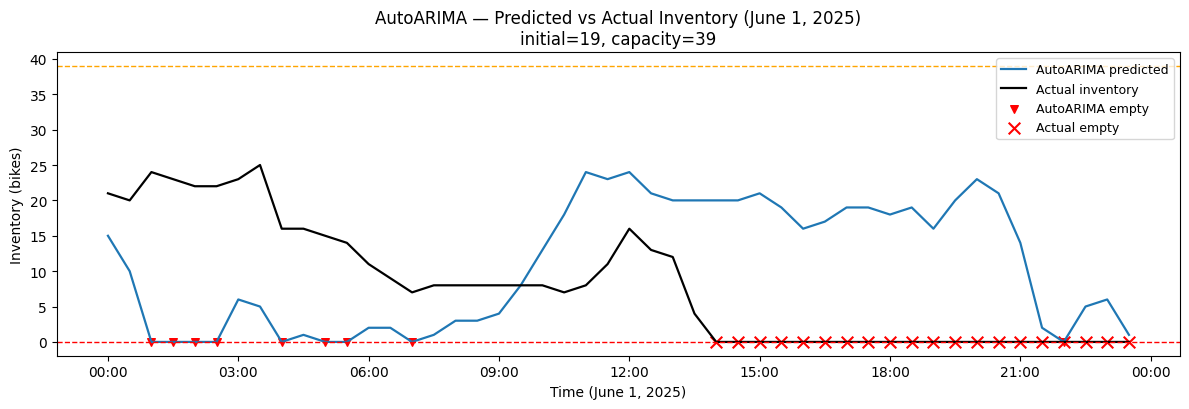


AutoARIMA diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.20058028241170928, 'pred_mean_before_fix': 1.2289924146422357, 'actual_mean': -1.0625, 'flipped_sign': True}
AutoARIMA predicted empty bins: 9, full bins: 0


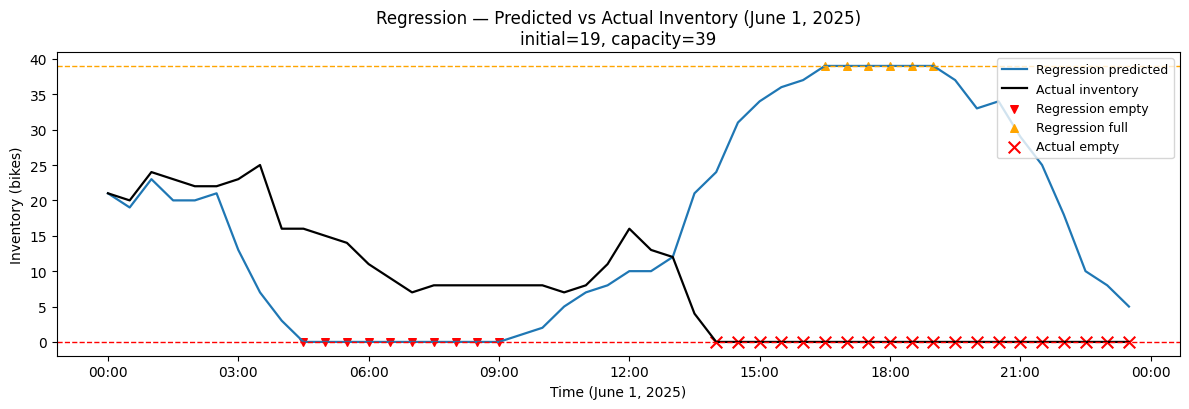


Regression diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.007490615958235531, 'pred_mean_before_fix': 0.4990773809523918, 'actual_mean': -1.0625, 'flipped_sign': True}
Regression predicted empty bins: 10, full bins: 6


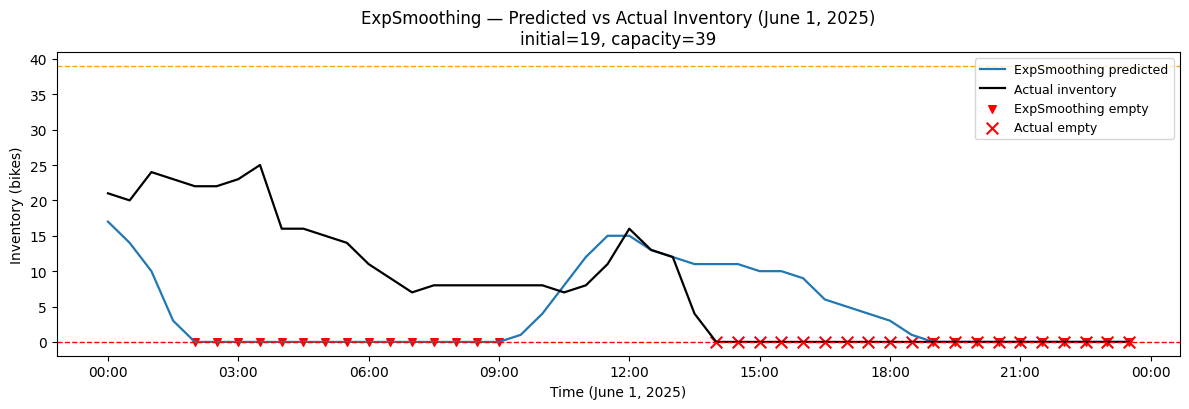


ExpSmoothing diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.1305461989040927, 'pred_mean_before_fix': 2.0959518835966, 'actual_mean': -1.0625, 'flipped_sign': True}
ExpSmoothing predicted empty bins: 25, full bins: 0


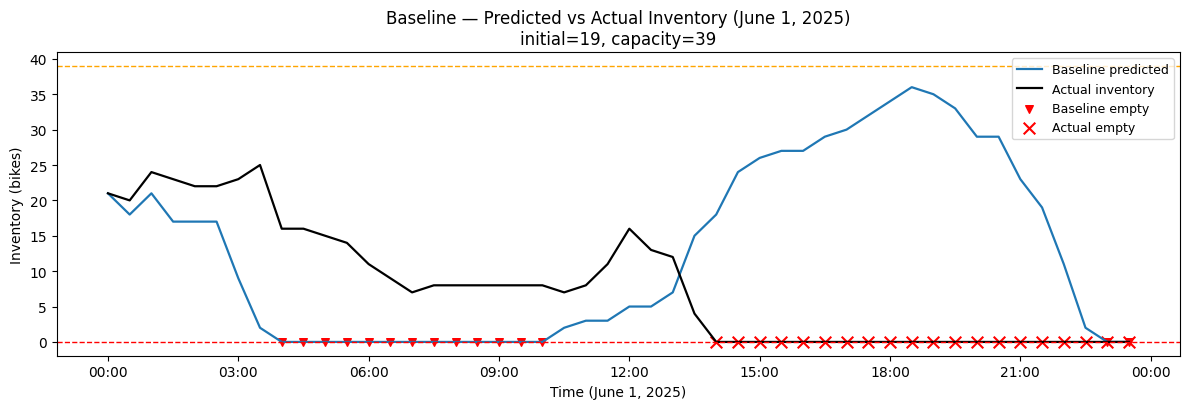


Baseline diagnostics: {'was_cumulative': False, 'corr_with_actual': -0.007490615958312056, 'pred_mean_before_fix': 1.1041666666666667, 'actual_mean': -1.0625, 'flipped_sign': True}
Baseline predicted empty bins: 15, full bins: 0


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

# --- User variables that must exist ---
# flows_june (full June), pred_arima, pred_reg, pred_hw, pred_base
# station_capacity, initial_bikes

# --- 1) Day window (June 1) and actual_day (ensure flows_june exists) ---
day_start = pd.Timestamp("2025-06-01 00:00:00")
day_end   = pd.Timestamp("2025-06-01 23:30:00")

flows_june = flows_june.copy()
flows_june['end_time'] = pd.to_datetime(flows_june['end_time'])
actual_day = flows_june[(flows_june['end_time'] >= day_start) & (flows_june['end_time'] <= day_end)].reset_index(drop=True)
day_index = actual_day['end_time']

# --- 2) Robust helper to produce per-bin pred_net_flow from any prediction DF ---
def build_pred_net_flow(pred_df):
    df = pred_df.copy()
    # unify time column names
    if 'ds' in df.columns and 'end_time' not in df.columns:
        df = df.rename(columns={'ds': 'end_time'})
    if 'end_time' not in df.columns:
        raise ValueError("Prediction DataFrame missing time column 'end_time' or 'ds'.")
    df['end_time'] = pd.to_datetime(df['end_time'])
    # direct column
    if 'pred_net_flow' in df.columns:
        df['pred_net_flow'] = df['pred_net_flow'].astype(float).fillna(0.0)
        return df
    # inflow/outflow pair
    if 'pred_inflow' in df.columns and 'pred_outflow' in df.columns:
        df['pred_net_flow'] = df['pred_inflow'].fillna(0) - df['pred_outflow'].fillna(0)
        return df
    # try *_in / *_out patterns
    in_cols = [c for c in df.columns if c.endswith('_in')]
    out_cols = [c for c in df.columns if c.endswith('_out')]
    if in_cols and out_cols:
        df['pred_net_flow'] = df[in_cols[0]].fillna(0) - df[out_cols[0]].fillna(0)
        return df
    # fallback: use first numeric column (last resort)
    numeric_cols = df.select_dtypes('number').columns.tolist()
    if numeric_cols:
        df['pred_net_flow'] = df[numeric_cols[0]].astype(float).fillna(0)
        return df
    # nothing found
    df['pred_net_flow'] = 0.0
    return df

# --- 3) Align to day index and detect sign / cumulative issues, fix them ---
def align_and_fix(pred_raw, reference_index, actual_net_flow):
    # build net flow
    df = build_pred_net_flow(pred_raw)
    # align to reference index (day_index)
    df = df.set_index('end_time').reindex(reference_index).reset_index().rename(columns={'index':'end_time'})
    df['pred_net_flow'] = df['pred_net_flow'].astype(float).fillna(0.0)
    # detect if predictions are cumulative (non-decreasing)
    diffs = np.diff(df['pred_net_flow'].fillna(0).values)
    was_cumulative = np.all(diffs >= -1e-8)
    if was_cumulative:
        # convert to per-bin by differencing
        df['pred_net_flow'] = df['pred_net_flow'].diff().fillna(df['pred_net_flow'].iloc[0])
    # compute correlation with actual net_flow (aligned)
    corr = np.nan
    try:
        valid = (~np.isnan(df['pred_net_flow'])) & (~np.isnan(actual_net_flow))
        if valid.sum() > 2:
            corr = np.corrcoef(actual_net_flow[valid], df['pred_net_flow'][valid])[0,1]
    except Exception:
        corr = np.nan
    # flip sign if correlation strongly negative or means have opposite sign
    pred_mean = df['pred_net_flow'].mean()
    actual_mean = np.nanmean(actual_net_flow)
    flip = False
    if not np.isnan(corr) and corr < -0.05:
        flip = True
    elif np.sign(pred_mean) != np.sign(actual_mean) and abs(pred_mean) > 0 and abs(actual_mean) > 0:
        flip = True
    if flip:
        df['pred_net_flow'] = -df['pred_net_flow']
    diagnostics = {
        'was_cumulative': bool(was_cumulative),
        'corr_with_actual': float(corr) if not np.isnan(corr) else None,
        'pred_mean_before_fix': float(pred_mean),
        'actual_mean': float(actual_mean),
        'flipped_sign': bool(flip)
    }
    return df, diagnostics

# --- 4) Prepare each model aligned to June 1 and diagnostics ---
models_raw = {
    'AutoARIMA': pred_arima,
    'Regression': pred_reg,
    'ExpSmoothing': pred_hw,
    'Baseline': pred_base
}

prepared = {}
diagnostics_all = {}
actual_net = actual_day['net_flow'].astype(float).values if 'net_flow' in actual_day.columns else (actual_day.get('inflow',0) - actual_day.get('outflow',0)).astype(float).values

for name, raw in models_raw.items():
    df_aligned, diag = align_and_fix(raw, day_index, actual_net)
    prepared[name] = df_aligned
    diagnostics_all[name] = diag

# --- 5) Inventory simulation (stepwise clipping) using pred_net_flow ---
def simulate_day_inventory_from_pred(pred_df, initial_bikes, capacity, round_flows=True):
    df = pred_df[['end_time','pred_net_flow']].copy()
    df['end_time'] = pd.to_datetime(df['end_time'])
    if round_flows:
        df['pred_net_flow_int'] = np.round(df['pred_net_flow'].astype(float)).astype(int)
    else:
        df['pred_net_flow_int'] = df['pred_net_flow'].astype(float)
    inv_unclipped = []
    current = initial_bikes
    for delta in df['pred_net_flow_int'].values:
        current = current + int(delta)
        inv_unclipped.append(current)
        # clip for next step
        if current < 0:
            current = 0
        elif current > capacity:
            current = capacity
    df['inventory_unclipped'] = inv_unclipped
    df['inventory_clipped'] = np.clip(df['inventory_unclipped'], 0, capacity)
    df['is_empty'] = df['inventory_clipped'] <= 0
    df['is_full']  = df['inventory_clipped'] >= capacity
    return df

# --- 6) Plot per-model predicted vs actual for June 1 with diagnostics printed ---
for name, pred in prepared.items():
    pred_sim = simulate_day_inventory_from_pred(pred, initial_bikes, station_capacity, round_flows=True)
    # ensure alignment (should already be aligned)
    pred_sim = pred_sim.set_index('end_time').reindex(day_index).reset_index()
    fig, ax = plt.subplots(figsize=(12, 4.2))
    # predicted inventory
    ax.plot(pred_sim['end_time'], pred_sim['inventory_clipped'], label=f"{name} predicted", color='C0', linewidth=1.6)
    # actual inventory (first day)
    ax.plot(actual_day['end_time'], actual_day['inventory_clipped'], label='Actual inventory', color='black', linewidth=1.6)
    # predicted markers
    if pred_sim['is_empty'].any():
        ax.scatter(pred_sim.loc[pred_sim['is_empty'],'end_time'], pred_sim.loc[pred_sim['is_empty'],'inventory_clipped'],
                   color='red', s=30, marker='v', label=f"{name} empty")
    if pred_sim['is_full'].any():
        ax.scatter(pred_sim.loc[pred_sim['is_full'],'end_time'], pred_sim.loc[pred_sim['is_full'],'inventory_clipped'],
                   color='orange', s=30, marker='^', label=f"{name} full")
    # actual markers
    actual_empty = actual_day['inventory_clipped'] <= 0
    actual_full  = actual_day['inventory_clipped'] >= station_capacity
    if actual_empty.any():
        ax.scatter(actual_day.loc[actual_empty,'end_time'], actual_day.loc[actual_empty,'inventory_clipped'],
                   color='red', s=70, marker='x', label='Actual empty')
    if actual_full.any():
        ax.scatter(actual_day.loc[actual_full,'end_time'], actual_day.loc[actual_full,'inventory_clipped'],
                   color='orange', s=70, marker='x', label='Actual full')
    # capacity lines
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.axhline(station_capacity, color='orange', linestyle='--', linewidth=1)
    # legend dedupe
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)
    ax.set_title(f"{name} — Predicted vs Actual Inventory (June 1, 2025)\ninitial={initial_bikes}, capacity={station_capacity}")
    ax.set_xlabel("Time (June 1, 2025)")
    ax.set_ylabel("Inventory (bikes)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout()
    plt.show()
    # print diagnostics for this model
    print(f"\n{name} diagnostics:", diagnostics_all[name])
    # quick stockout counts
    print(f"{name} predicted empty bins: {int(pred_sim['is_empty'].sum())}, full bins: {int(pred_sim['is_full'].sum())}")

# --- 7) Optional: return prepared and diagnostics for further inspection ---
# prepared (per-model aligned DataFrames) and diagnostics_all are available in the notebook

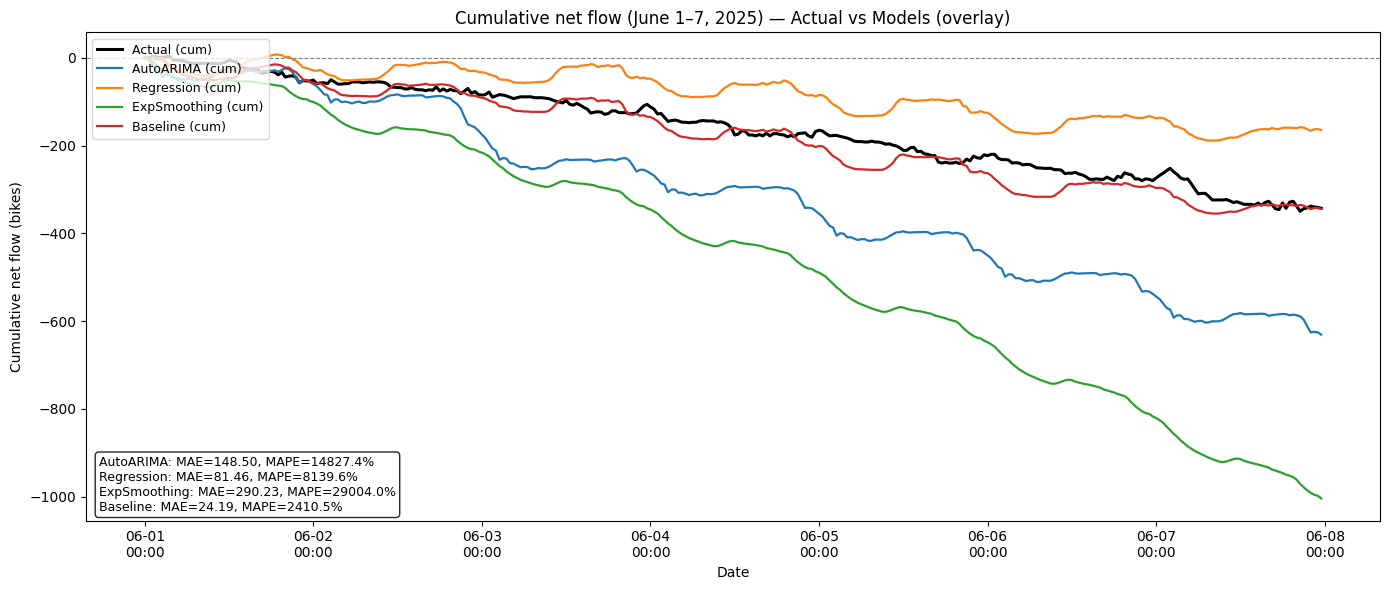

Diagnostics per model (was_cumulative, flipped_sign, pred_mean, actual_mean, corr_with_actual):
AutoARIMA: {'was_cumulative': False, 'pred_mean': 1.8879596582478104, 'actual_mean': -1.0148809523809523, 'corr_with_actual': 0.07980952906015958, 'flipped_sign': True}
Regression: {'was_cumulative': False, 'pred_mean': 0.48238095238131384, 'actual_mean': -1.0148809523809523, 'corr_with_actual': 0.013599885849196927, 'flipped_sign': True}
ExpSmoothing: {'was_cumulative': False, 'pred_mean': 2.993661109056887, 'actual_mean': -1.0148809523809523, 'corr_with_actual': 0.005974496623027472, 'flipped_sign': True}
Baseline: {'was_cumulative': False, 'pred_mean': 1.0202380952380952, 'actual_mean': -1.0148809523809523, 'corr_with_actual': 0.0143983308437144, 'flipped_sign': True}

Cumulative-series metrics (June 1–7):
AutoARIMA: MAE_cum = 148.505, MAPE_cum = 14827.44%
Regression: MAE_cum = 81.462, MAPE_cum = 8139.59%
ExpSmoothing: MAE_cum = 290.230, MAPE_cum = 29004.00%
Baseline: MAE_cum = 24.192, MA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Preconditions (must exist) ---
# flows_june: DataFrame with 'end_time' datetime and 'net_flow' (per 30min) for June
# pred_arima, pred_reg, pred_hw, pred_base: DataFrames with time + predictions
#    predictions may be in columns: 'pred_net_flow' OR 'pred_inflow'/'pred_outflow' OR '<model>_in'/'<model>_out' OR 'ds'
# station_capacity, initial_bikes may exist (not required for cumsum overlay)

# --- Helper utilities ---
def detect_and_build_pred_net(df):
    """Return a copy with a numeric 'pred_net_flow' column inferred robustly."""
    tmp = df.copy()
    # unify time column names
    if 'ds' in tmp.columns and 'end_time' not in tmp.columns:
        tmp = tmp.rename(columns={'ds':'end_time'})
    if 'end_time' not in tmp.columns:
        raise ValueError("Prediction DataFrame missing time column 'end_time' or 'ds'.")
    tmp['end_time'] = pd.to_datetime(tmp['end_time'])
    # direct column
    if 'pred_net_flow' in tmp.columns:
        tmp['pred_net_flow'] = tmp['pred_net_flow'].astype(float).fillna(0.0)
        return tmp
    # inflow/outflow pair
    if 'pred_inflow' in tmp.columns and 'pred_outflow' in tmp.columns:
        tmp['pred_net_flow'] = tmp['pred_inflow'].fillna(0) - tmp['pred_outflow'].fillna(0)
        return tmp
    # try *_in / *_out patterns
    in_cols = [c for c in tmp.columns if c.endswith('_in')]
    out_cols = [c for c in tmp.columns if c.endswith('_out')]
    if in_cols and out_cols:
        tmp['pred_net_flow'] = tmp[in_cols[0]].fillna(0) - tmp[out_cols[0]].fillna(0)
        return tmp
    # fallback: try any numeric column (last resort)
    numeric_cols = tmp.select_dtypes('number').columns.tolist()
    if numeric_cols:
        tmp['pred_net_flow'] = tmp[numeric_cols[0]].astype(float).fillna(0)
        return tmp
    # nothing found
    tmp['pred_net_flow'] = 0.0
    return tmp

def reindex_to_index(df, index):
    df2 = df.set_index('end_time').reindex(index).reset_index().rename(columns={'index':'end_time'})
    return df2

def is_cumulative(series):
    """Heuristic: cumulative series is non-decreasing (allow small noise)."""
    s = np.asarray(series, dtype=float)
    if len(s) < 3:
        return False
    diffs = np.diff(s)
    # allow tiny negative noise
    return np.all(diffs >= -1e-6)

# --- 1) Build week index and actual cumulative series ---
week_start = pd.Timestamp("2025-06-01 00:00:00")
week_end   = pd.Timestamp("2025-06-07 23:30:00")
week_index = pd.date_range(start=week_start, end=week_end, freq='30min')

flows_june = flows_june.copy()
flows_june['end_time'] = pd.to_datetime(flows_june['end_time'])
actual_week = flows_june.set_index('end_time').reindex(week_index).fillna(0).reset_index().rename(columns={'index':'end_time'})
if 'net_flow' not in actual_week.columns:
    actual_week['net_flow'] = actual_week.get('inflow', 0) - actual_week.get('outflow', 0)
actual_week['net_flow'] = actual_week['net_flow'].astype(float)
actual_week['cum_net_flow'] = actual_week['net_flow'].cumsum()
actual_week['cum_net_flow'] -= actual_week['cum_net_flow'].iloc[0]  # zero baseline

# --- 2) Prepare models robustly and detect issues ---
raw_models = {
    'AutoARIMA': pred_arima,
    'Regression': pred_reg,
    'ExpSmoothing': pred_hw,
    'Baseline': pred_base
}

prepared = {}
diagnostics = {}

for name, raw in raw_models.items():
    tmp = detect_and_build_pred_net(raw)
    # align to week index
    tmp = reindex_to_index(tmp.set_index('end_time').reset_index(), week_index)
    # if the series looks cumulative (non-decreasing), convert to per-bin by differencing
    if is_cumulative(tmp['pred_net_flow'].fillna(0).values):
        tmp['pred_net_flow'] = tmp['pred_net_flow'].diff().fillna(tmp['pred_net_flow'].iloc[0])
        diagnostics[name] = diagnostics.get(name, {})
        diagnostics[name]['was_cumulative'] = True
    else:
        diagnostics[name] = diagnostics.get(name, {})
        diagnostics[name]['was_cumulative'] = False
    # compute simple stats vs actual
    pred_mean = tmp['pred_net_flow'].mean()
    actual_mean = actual_week['net_flow'].mean()
    corr = np.nan
    try:
        valid = (~tmp['pred_net_flow'].isna()) & (~actual_week['net_flow'].isna())
        if valid.sum() > 2:
            corr = np.corrcoef(actual_week['net_flow'][valid], tmp['pred_net_flow'][valid])[0,1]
    except Exception:
        corr = np.nan
    diagnostics[name]['pred_mean'] = float(pred_mean)
    diagnostics[name]['actual_mean'] = float(actual_mean)
    diagnostics[name]['corr_with_actual'] = float(corr) if not np.isnan(corr) else None
    # if correlation is strongly negative or means have opposite sign, flip sign
    flip = False
    if corr is not None and not np.isnan(corr) and corr < -0.05:
        flip = True
    elif np.sign(pred_mean) != np.sign(actual_mean) and abs(pred_mean) > 0 and abs(actual_mean) > 0:
        flip = True
    if flip:
        tmp['pred_net_flow'] = -tmp['pred_net_flow']
        diagnostics[name]['flipped_sign'] = True
    else:
        diagnostics[name]['flipped_sign'] = False
    # store
    prepared[name] = tmp

# --- 3) Compute cumulative predicted net flow (zero baseline) and metrics ---
def mae(a,b): return np.mean(np.abs(np.array(a)-np.array(b)))
def mape(a,b): return np.mean(np.abs((np.array(a)-np.array(b))/np.clip(np.array(a),1,None)))*100

metrics = {}
for name, df in prepared.items():
    df['cum_pred_net_flow'] = df['pred_net_flow'].cumsum()
    df['cum_pred_net_flow'] -= df['cum_pred_net_flow'].iloc[0]
    pred_cum = df['cum_pred_net_flow'].values
    actual_cum = actual_week['cum_net_flow'].values
    metrics[name] = {
        'MAE_cum': float(mae(actual_cum, pred_cum)),
        'MAPE_cum': float(mape(actual_cum, pred_cum))
    }

# --- 4) Plot overlay of all cumulative series on same axes ---
plt.figure(figsize=(14,6))
plt.plot(actual_week['end_time'], actual_week['cum_net_flow'], color='black', linewidth=2.2, label='Actual (cum)')
colors = {'AutoARIMA':'C0','Regression':'C1','ExpSmoothing':'C2','Baseline':'C3'}
for name, df in prepared.items():
    plt.plot(df['end_time'], df['cum_pred_net_flow'], color=colors.get(name,'C7'), linewidth=1.6, label=f"{name} (cum)")

# annotate metrics
txt_lines = [f"{name}: MAE={metrics[name]['MAE_cum']:.2f}, MAPE={metrics[name]['MAPE_cum']:.1f}%" for name in metrics]
plt.gca().text(0.01, 0.02, "\n".join(txt_lines), transform=plt.gca().transAxes, fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("Cumulative net flow (June 1–7, 2025) — Actual vs Models (overlay)")
plt.xlabel("Date")
plt.ylabel("Cumulative net flow (bikes)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# --- 5) Print diagnostics to help interpret results ---
print("Diagnostics per model (was_cumulative, flipped_sign, pred_mean, actual_mean, corr_with_actual):")
for name, d in diagnostics.items():
    print(f"{name}: {d}")
print("\nCumulative-series metrics (June 1–7):")
for name, m in metrics.items():
    print(f"{name}: MAE_cum = {m['MAE_cum']:.3f}, MAPE_cum = {m['MAPE_cum']:.2f}%")